# Workshop 1: Short-Form Content Recommendation Algorithms 📱

- **When**: Friday 18th September 2026, 16:00 - 18:00
- **Where**: Appleton Tower
- **Contact**: hello@edinburghai.org
- **Credits**: This notebook was created by Conor O'Shea for EdinburghAI workshops. If you plan to use it, please credit us!

---

# What's this notebook about? 🤔

Today we'll explore the Hierarchical Sequential Transduction Unit (HSTU), an architecture introduced by Meta for large-scale sequential recommendation. 

By the end, you'll have built and trained your own HSTU model that learns from your scrolling behaviour to recommend reels tailored to you!


<br>

### What we are doing today:

We'll be implementing our very own HSTU model in PyTorch, which will learn from your interactions and use them to power your personal reels recommender!


<br>


<br>

<img src="https://substackcdn.com/image/fetch/$s_!z696!,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F855e4806-d9a3-4e57-a070-f74378564d4d_864x1014.png" width="500"/>

<hr>

# The Structure of this notebook 📖

This notebook is split into 3 main sections, the first 2 being more theory-focused and the final one being where you build your own model.

<br>

**Main goal**

Complete all of the tasks in each of the sections.

*We'd recommend working through them in order.*

<br>

**What sort of things you'll need to do for tasks**

Some tasks will be filling in the blanks for parameters
Others may allow a more open approach, telling you what a function should output and letting you go about implementing it whichever way you like

<br>

**Tech stack used**

- [Pytorch](https://pytorch.org/)
- [Python](https://www.python.org/)

<hr>

# Section 1: User Interaction Sequences 📱

One of the most important ideas in modern recommendation systems is that a user's interests are revealed not only by **what they interact with**, but also by **the order in which those interactions happen**.

## What is a user interaction sequence?

A user interaction sequence is a time-ordered record of the content shown to a user and how they responded to it.

For example, imagine that a user named John is scrolling through reels:

1. John is shown a cat video.
2. He watches it for 10 seconds and likes it.
3. He scrolls to the next reel.
4. He is shown a video about chess.
5. He watches it for 2 seconds and immediately skips it.
6. He is shown a university meme.
7. He watches most of it and opens the comments.

We can represent this as a sequence of events:

```text
Position 1
Reel: Cat video
Watch time: 10 seconds
Liked: Yes
Opened comments: No

Position 2
Reel: Chess video
Watch time: 2 seconds
Liked: No
Opened comments: No

Position 3
Reel: University meme
Watch time: 8 seconds
Liked: No
Opened comments: Yes
```

The order matters. John's interest in cat videos and university memes, along with his quick skip of the chess video, may help the recommender decide what to show next.


## How can computers understand user interaction sequences?

A computer cannot directly understand concepts such as "cat video", "liked", or "quickly skipped". These must first be converted into numbers.

### What is an embedding?

An **embedding** is a way of representing something (a video, a word, a user) as a list of numbers called a **vector**. The idea is that similar things end up with similar vectors, so a cat video and a dog video might have vectors that are close together, while a cat video and a chess video would be further apart. This lets a model do mathematics on concepts it would otherwise have no way to compare.

### Representing each event

Each event can be represented using:

- **Item embedding**: a vector (a list of numbers) that encodes the reel's content in a form the model can process
- **Watch information**: signals like watch time and watch ratio that indicate how much of the reel the user consumed
- **Action information**: explicit user responses such as likes, shares, or skips
- **Timing information**: when the interaction occurred, which can indicate recency or session context
- **Position in sequence**: the event's index in the ordered history, which helps the model understand temporal order

This produces a sequence of numerical event representations:

```text
Reel metadata
      ↓
Item embedding
      +
Watch and action features
      +
Time and position
      ↓
Event embedding
```

A sequential recommendation model can then examine these event embeddings in order and learn patterns in how a user's interests develop.

For example, it might learn that:

- liking several university memes suggests an interest in similar content
- immediately skipping several chess videos suggests less interest in chess
- recent interactions may be more useful than much older interactions
- a user's interests may change during a scrolling session

In the next tasks, we will turn a small collection of scrolling events into an ordered interaction sequence and identify which information a recommender can use when making its next prediction.

## Task 1.0: Turn scrolling behaviour into a sequence 🔢

The events below are not in chronological order. Sort them by timestamp to reconstruct the user’s interaction sequence.

In [1]:
events = [
    {
        "item": "chess video",
        "timestamp": 16,
        "watch_seconds": 2,
        "liked": False,
    },
    {
        "item": "cat video",
        "timestamp": 4,
        "watch_seconds": 10,
        "liked": True,
    },
    {
        "item": "university meme",
        "timestamp": 27,
        "watch_seconds": 8,
        "liked": True,
    },
]

# TODO: Sort the list of events from earliest to latest.
sequence = sorted(events, key=lambda event: event["timestamp"])

for position, event in enumerate(sequence):
    print(position, event)


0 {'item': 'cat video', 'timestamp': 4, 'watch_seconds': 10, 'liked': True}
1 {'item': 'chess video', 'timestamp': 16, 'watch_seconds': 2, 'liked': False}
2 {'item': 'university meme', 'timestamp': 27, 'watch_seconds': 8, 'liked': True}


## Task 1.1: Separate History, Candidate, and Target 🔮

Suppose the model is about to recommend the university meme.

Classify each field as either of the string literals:

- "history"
- "candidate input"
- "prediction target"

Where:

- "history" means information from interactions that happened before the current recommendation
- "candidate input" means information already known about the reel the model is considering recommending
- "prediction target" means an outcome the model is trying to predict for the current candidate, such as whether the user will like or skip it


**Your Job**

Complete the code below by assigning one of these three labels to each field:

In [2]:
# Todo: 
# Replace each None with:
# "history", "candidate input", or "prediction target"

features = {
    "previous_cat_video_liked": "history",
    "previous_chess_watch_seconds": "history",
    "candidate_content_embedding": "candidate input",
    "candidate_duration_sec": "candidate input",
    "candidate_liked": "prediction target",
    "candidate_watch_ratio": "prediction target",
}


<hr>

# Section 2: The Hierarchical Sequential Transduction Unit (HSTU)

The HSTU was introduced in Meta's paper [Actions Speak Louder Than Words](https://arxiv.org/pdf/2402.17152).



## The basic idea 

Just as an LLM can treat text as a sequence of tokens, a recommender can treat a user's scrolling history as a sequence of tokens and learn patterns from the order of those tokens.

<br>

## What input does the HSTU expect?

However, giving every raw micro-action its own token is impractical. A single session might involve hundreds of taps, scrolls, and pauses, and a user's full history spans months. The sequence would become far too long to process efficiently.

Instead, we compress the raw event stream down to two tokens per video: a content token and an action token, placed one after the other in the sequence rather than fused together.

Each pair therefore captures:

- Content token: an embedding of what the video is about
- Action token: a vector of the explicit actions taken on it, likes, shares, comments, skips

<br>

This means that a raw sequence like:

1. Cat video
2. Dwell for 10 seconds
3. Like
4. Open comments
5. Close comments
6. Scroll
7. Dog video
8. Dwell for 3 seconds
9. Scroll
10. Politics video
11. Dwell for 120 seconds
12. Open comments
13. Scroll comments for 15 seconds
14. Close comments
15. Like
16. Share

Gets compressed into a sequence of (video, action vector) pairs before the HSTU ever sees it:

```
[cat_video, {like, opened_comments}, dog_video, {skip}, politics_video, {like, shared, commented}]
```

Six tokens for three videos, not three, since content and action are kept as separate tokens rather than merged into one.

However, remember that a computer cannot directly understand something like "cat video". We need to convert it into a numerical representation, known as an embedding.

Once we have this sequence of tokens, each content and action token is passed through an embedding layer (with an optional small MLP) to become a numerical vector. This gives us a sequence of embeddings that is ready to be processed by the HSTU.

<br>


## How does the HSTU work?

The HSTU is built on the transformer architecture, the same architecture that powers LLMs like ChatGPT. If you haven't come across transformers before, the key idea is that they're good at looking at a sequence and figuring out which parts of it are most relevant to each other based on their position in the sequence.

However, the HSTU makes a couple of changes to the standard transformer architecture introduced in [Attention Is All You Need](https://arxiv.org/pdf/1706.03762).


Meta made two main tweaks when adapting this for recommendations:

**1. No softmax in the attention step**

In a standard transformer, the model computes an attention score for each item in the sequence:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d}}\right)V$$

These scores control how much each past interaction influences the final representation of the user. In a standard transformer these scores are normalised using the softmaxsoftmax function so they sum to 1, meaning the model has a fixed "attention budget" to spread across the user's history. If the politics video gets more attention, the cat video automatically gets less. For recommendations this is a problem. When building up a picture of a user's interests, you want strong engagement with multiple different videos to all contribute equally.

So the HSTU drops this normalisation and replaces softmax with a point-wise activation ($\text{SiLU}$):

$$\text{HSTU-Attention}(Q, K, V) = \text{SiLU}(QK^T) V$$

Because there is no longer a denominator forcing the scores to sum to 1, signals from different interactions accumulate independently.

<br>

**2. A relative attention bias for position and time**

Standard transformers rely on categorical positional indices ($1, 2, 3, \dots$).

The HSTU instead folds a bias directly into the attention score, one that captures both the relative position of two events in the sequence and the elapsed time between them. The model differentiates between a video watched two minutes ago versus one watched three weeks ago, allowing recency decay to emerge naturally.

<br>

**Why not just use a standard transformer?**

The short answer is scale. Meta is running this for billions of users across trillions of interactions. A standard transformer's attention step gets very expensive very quickly as sequences get longer. These changes make it feasible to run in under 50ms per recommendation.

Importantly, this is not much of a tradeoff. The changes Meta made are not just engineering shortcuts, they are actually a better fit for the problem. Softmax normalisation made sense for language, where you want the model to focus on specific words. For recommendations, you want all strong engagement signals to survive, so dropping it actually improves the model as well as speeding it up.

<br>


## The HSTU's output

There are actually 2 possible output formats for the HSTU, depending on what you're trying to predict:

- A score for each candidate reel directly
- A probability for each possible action type for each candidate reel (e.g. how likely is the user to like it, share it, or skip it)


In practice the latter is much more common in production systems. Rather than asking "how good is this reel for this user?", the model instead asks "what is this user likely to do if we show them this reel?". This gives a much richer picture of how the user is likely to respond, and is a more faithful representation of what actually happened in the training data.

It also gives the platform flexibility: the predicted action probabilities can be combined into a final ranking score using a weighted sum:

$$\text{Final Score} = w_{\text{like}} \cdot P(\text{like}) + w_{\text{share}} \cdot P(\text{share}) + w_{\text{watch}} \cdot P(\text{completion}) - w_{\text{skip}} \cdot P(\text{skip})$$

The weights can be adjusted to reflect what the platform wants to optimise for at any given time. Want to push shares? Increase the share weight. Want to reduce passive scrolling? Increase the weight on active signals like comments.

<br>

**How the approach works**

Say we have narrowed our search space down to 200 candidate reels. For each one, the model:

1. Appends the candidate reel as the final token in the user's interaction sequence
2. Lets the candidate attend to the user's history using the HSTU (in practice, the user's history is processed once and cached, so all 200 candidates can evaluate against it in parallel)
3. Takes the output at the candidate's position
4. Passes it through a small prediction head (usually just some feed-forward layers) that outputs a probability for each action type (watch completion, like, share, skip, etc.)
5. Combines those probabilities into a single ranking score using the weighted sum formula above

You then simply order the reels in terms of their final score and deliver the reels with the top $n$ scores to the user.

*Note: The history stays fixed; each candidate simply takes turns stepping into the final slot to see how well it fits.*




<hr>

# Section 3: Building Our Own Reels Recommender 

Now it's time to build the full thing!

The idea here is to take what we've just learned about user interaction sequences and the HSTU, and build our own model in Pytorch that will recommend Reels to you based on a given user interaction sequence.

Although we'll be using our recommender for Instagram Reels, there doesn't currently exist an easy-to-access dataset for user interaction sequences on instagram reels.

However, there are easily accessible datasets for similar Chinese short-form content platforms that give us the same information.

For that reason we'll be using an adapted version of the [short video 2025 dataset](https://github.com/tsinghua-fib-lab/ShortVideo_dataset) 

## Task 3.0: Add the workshop dataset 📂

As said above, we'll be training our reels classifer on data that has been adapted from the short video 2025 dataset

It'll need to be imported to your notebook before it can be used.


**Your Job:**

Import the dataset to this dataset using the 'add input' option in the right side bar.

The you've to import can be found here: https://www.kaggle.com/datasets/conoroshea46/ediai-reels-adapted-short-video-2025-dataset

<br>

**Need Help?**

Feel free to ask one of us coming around!

## Task 3.1: Load the Dataset into Python ⚙️

Our dataset is not much use if it is just sitting in a folder. Lets load it into the notebook!

The dataset contains several files:

- `events.parquet`
- `items.parquet`
- `item_categories.parquet`
- `content_embeddings.npy`
- `item_embedding_index.csv`
- `processing_metadata.json`
- `embedding_metadata.json`
- `SHA256SUMS`
- `requirements.txt`

The main files we need for training are:

- `events.parquet`, containing the user interaction sequences
- `items.parquet`, containing the video metadata
- `content_embeddings.npy`, containing the precomputed video embeddings
- `item_embedding_index.csv`, mapping each `item_id` to its embedding

<br>

**Where the data will be located in your notebook:**

When you added the dataset, kaggle will have stored it in your notebook's "/kaggle/input/datasets" directory in a sub directory named after the dataset's creator's kaggle account name.

This means the path to the dataset should be "/kaggle/input/datasets/conoroshea46/ediai-reels-adapted-short-video-2025-dataset"

<br>

**Your Job:**

You'll need to load these files as the following types:

- "events.parquet" as its own pandas dataframe
- "items.parquet" as its own pandas dataframe
- "content_embeddings.npy" as its own numpy array
- "item_embedding_index.csv" as its own pandas dataframe


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd


DATASET_DIR_PATH = Path("/kaggle/input/datasets/conoroshea46/ediai-reels-adapted-short-video-2025-dataset")

events_df: pd.DataFrame = pd.read_parquet(DATASET_DIR_PATH / "events.parquet")
items_df: pd.DataFrame = pd.read_parquet(DATASET_DIR_PATH / "items.parquet")

content_embeddings: np.ndarray = np.load(DATASET_DIR_PATH / "content_embeddings.npy")

item_embedding_index_df: pd.DataFrame = pd.read_csv(DATASET_DIR_PATH / "item_embedding_index.csv")

## Task 3.2: Let's Have a Look at Some of the Columns in Our Data 🔍

Before building our model, let us inspect the data we have loaded.

- `events_df` contains the user interaction events.
- `items_df` contains metadata about each video.

The two tables are connected using the `item_id` column.

Each video also has a precomputed content embedding made up of 768 numbers. These embeddings were generated from the video's title, categories, and tags using the `intfloat/multilingual-e5-base` text encoder.

The individual numbers in an embedding do not have clear meanings on their own. Instead, the complete vector represents the video's content, allowing videos with similar metadata to be placed closer together.

The embeddings are stored in `content_embeddings`, while `item_embedding_index_df` maps each `item_id` to the correct row in that array.

<br>

**What are embeddings again?**

Embeddings are numerical representations of information. In this dataset, each video is represented by a list of 768 numbers describing its content.

Videos with similar titles, categories, and tags should generally have similar embeddings. This gives our model a way to compare the meaning of different videos using numbers.

<br>

**Your Job**

1. Display the columns in the event and item tables.
2. Display the first few rows of both tables. The first few rows are also known as the `head` of a table.
3. Display the shape of `content_embeddings` to see how many embeddings there are and how many features (numbers) each one contains.

In [4]:
print("Event columns:")
print(events_df.columns.tolist())

print("\nFirst few event rows:")
display(events_df.head())

print("\nItem columns:")
print(items_df.columns.tolist())

print("\nFirst few item rows:")
display(items_df.head())

print("\nContent embeddings shape:")
print(content_embeddings.shape)

Event columns:
['user_id', 'session_id', 'item_id', 'timestamp', 'sequence_position', 'watch_seconds', 'duration_sec', 'watch_ratio_raw', 'watch_ratio', 'watched_over_duration', 'watch_bucket', 'long_watch', 'immediate_skip', 'liked', 'negative_feedback', 'clicked', 'commented', 'followed', 'collected', 'forwarded', 'hate', 'not_interested', 'source', 'synthetic', 'processing_version']

First few event rows:


,user_id,session_id,item_id,timestamp,sequence_position,watch_seconds,duration_sec,watch_ratio_raw,watch_ratio,watched_over_duration,...,clicked,commented,followed,collected,forwarded,hate,not_interested,source,synthetic,processing_version
0,shortvideo:1,shortvideo:1:session:1,shortvideo:63980,1663598611,0,111,112.000,0.991071,0.991071,False,...,True,False,False,False,False,False,<NA>,short_video_2025,False,metadata-v1.0
1,shortvideo:1,shortvideo:1:session:2,shortvideo:37412,1663794733,0,131,128.600,1.018663,1.000000,True,...,True,False,False,False,False,False,<NA>,short_video_2025,False,metadata-v1.0
2,shortvideo:1,shortvideo:1:session:2,shortvideo:6004,1663794733,1,143,137.200,1.042274,1.000000,True,...,True,False,False,False,False,False,<NA>,short_video_2025,False,metadata-v1.0
3,shortvideo:10,shortvideo:10:session:1,shortvideo:34477,1663301840,0,18,16.933,1.063013,1.000000,True,...,True,False,False,False,False,False,<NA>,short_video_2025,False,metadata-v1.0
4,shortvideo:10,shortvideo:10:session:2,shortvideo:98000,1663330110,0,10,7.800,1.282051,1.000000,True,...,True,False,False,False,False,False,<NA>,short_video_2025,False,metadata-v1.0



Item columns:
['item_id', 'pid', 'title_cn', 'categories_en', 'categories_cn', 'tags_cn', 'duration_sec', 'content_text', 'creator_id', 'author_fans_count', 'source', 'synthetic', 'processing_version', 'embedding_row']

First few item rows:


,item_id,pid,title_cn,categories_en,categories_cn,tags_cn,duration_sec,content_text,creator_id,author_fans_count,source,synthetic,processing_version,embedding_row
0,shortvideo:1,1,站住!打劫手机,"[Star Entertainment, star]","[明星娱乐, 明星]",[快手观星记],14.733,Title: 站住!打劫手机\nCategories: Star Entertainment...,shortvideo_creator:520560003,10240304.0,short_video_2025,False,metadata-v1.0,0
1,shortvideo:2,2,加绒保暖,"[wear it, match display, fashion products]","[穿搭, 搭配展示, 穿搭售卖]","[拒绝emo请你快乐, 记得照顾好自己, 我的冬日穿塔]",9.200,Title: 加绒保暖\nCategories: wear it; match displa...,shortvideo_creator:1107894491,139721.0,short_video_2025,False,metadata-v1.0,1
2,shortvideo:3,3,加绒保暖,"[wear it, match display]","[穿搭, 搭配展示]","[快手时尚生产小能手, 拒绝emo请你快乐, 记得照顾好自己]",11.500,Title: 加绒保暖\nCategories: wear it; match displa...,shortvideo_creator:1107894491,140180.0,short_video_2025,False,metadata-v1.0,2
3,shortvideo:4,4,神仙球!!,"[movement, ball games, basketball]","[运动, 球类运动, 篮球]","[神仙球, 铁子的篮球]",21.638,Title: 神仙球!!\nCategories: movement; ball games...,shortvideo_creator:115768959,1545114.0,short_video_2025,False,metadata-v1.0,3
4,shortvideo:5,5,植物染发梳轻松遮盖白头发,"[beauty, hairdressing]","[美妆, 美发]","[遮盖白发, 植物染发安全健康, 美妆百万新星计划]",20.266,Title: 植物染发梳轻松遮盖白头发\nCategories: beauty; haird...,shortvideo_creator:50103091,406159.5,short_video_2025,False,metadata-v1.0,4



Content embeddings shape:
(31496, 768)


## Task 3.3: Split your datasets into training, validation, and test data 🔀

Whenever we train a machine-learning model, we usually split our data into three subsets:

- **Training data:** used to teach the model by updating its parameters
- **Validation data:** used to check how well different model settings work, such as the learning rate or number of HSTU layers
- **Test data:** used at the very end to measure how well the finished model performs on unseen data

It is important that we do not use the test data while making decisions about the model. If we repeatedly check the test results and change the model based on them, the test data is no longer truly unseen and our final results may appear better than they really are.

<br>

### How do we split the data between the 3?

We will use the following split:

- **Training data:** 80%
- **Validation data:** 10%
- **Test data:** 10%

Usually, datasets are randomly divided between these three subsets. However, we **cannot randomly split user interaction sequences**.

This is because our model is trying to use a user's past interactions to predict what they will interact with next. If we randomly split the events, the model could be trained using interactions that happened later and then tested using interactions that happened earlier.

For example, a random split could produce this:

```text
Monday interaction     → test
Tuesday interaction    → training
Wednesday interaction  → training
```

The model would then be learning from Tuesday and Wednesday while being tested on Monday. In other words, it would be learning from the future.

Instead, we must preserve chronological order:

```text
Past                                                     Future
|---------------- Training ----------------|-- Validation --|-- Test --|
```

The earliest 80% of events will be used for training, the next 10% for validation, and the remaining 10% for testing.


<br>

### Why use an 80/10/10 split?

There is no single correct percentage split in this scenario. We are using 80/10/10 because it gives the model most of the available events for training while still leaving enough later events for validation and final testing.

With approximately 129,000 events, this gives us roughly:

- **103,000 training events**
- **13,000 validation events**
- **13,000 test events**

You'll frequently see the 80/10/10 split come up in other machine learning models as it's just quite standard.

<br>


### How do we create the split in Python?

Scikit-learn provides a function called `train_test_split()` for splitting data into two parts.

However, we need three parts. We therefore need to:

1. Split the chronologically ordered events into 80% training data and 20% remaining data.
2. Split the remaining data equally between validation and test data.

This gives us:

```text
80% training | 10% validation | 10% test
```

Most importantly, we need to set `shuffle=False` so that Scikit-learn does not randomly rearrange the events.


<br>

### Your Job

Sort `events_df` from earliest to latest, use `train_test_split()` to create an 80/10/10 split without shuffling, and record each event's split in a new column.


In [5]:
from sklearn.model_selection import train_test_split

# split 80/20
train_events_df, remaining_events_df = train_test_split(
    events_df.sort_values("timestamp"),
    train_size=0.8,
    shuffle=False,
)

# Split the remaining 20 into 10/10
validation_events_df, test_events_df = train_test_split(
    remaining_events_df,
    test_size=0.5,
    shuffle=False,
)

print(f"Training events: {len(train_events_df):,}")
print(f"Validation events: {len(validation_events_df):,}")
print(f"Test events: {len(test_events_df):,}")


Training events: 103,586
Validation events: 12,948
Test events: 12,949


## Task 3.4: Build Our Training Sequences and Labels 🎯

Our dataset tells us what each user interacted with, but it does not contain a separate column telling the HSTU what it should predict.

We'll need to create these labels from the interaction sequences ourselves.

<br>

### How do we actually train an HSTU?

We'll train our HSTU to predict the next item in a user's interaction sequence.

For example, suppose a user has the following history:

```text
Cat video → Dog video → Politics video → University meme
```

We can shift this sequence by one position to create the inputs and labels:

```text
Inputs:  [Cat video, Dog video, Politics video]
Labels:  [Dog video, Politics video, University meme]
```

At each position, the model uses the interactions it has seen so far to predict the next item.

Thanks to causal attention, the HSTU can make all these predictions in a single pass. Each position is only allowed to use information from that position and the positions before it.

<br>

### Why do we need numerical labels?

Our item IDs are strings such as:

```text
shortvideo:36548
```

PyTorch expects numerical labels such as:

```text
0, 1, 2, 3, ...
```

Fortunately, `item_embedding_index_df` already maps every `item_id` to a numerical `embedding_row`. We'll use this row number as the item's class label.

<br>

### How long should each sequence be?

Some users have much longer histories than others. To keep memory usage and training time manageable, we'll limit each sequence to 50 input interactions.

Histories containing more than 50 interactions will be divided into smaller windows. Shorter sequences will remain at their original length for now. We'll pad them when creating batches in the next task.

<br>

### Which split should each label belong to?

The split is determined by the item we are trying to predict.

For example:

```text
Training-period interaction → Validation-period target
```

This prediction belongs to the validation data because the target interaction occurred during the validation period.

<br>

### Your Job

1. Record whether each event belongs to the training, validation, or test data.
2. Combine the three event tables and order each user's interactions chronologically.
3. Convert each `item_id` into its numerical class label.
4. Divide each user's history into sequences containing at most 50 input interactions.
5. Shift each sequence by one position to create its next-item labels.
6. Record which data split each target item belongs to.

In [6]:
import numpy as np
import pandas as pd


MAX_SEQUENCE_LENGTH: int = 50

SPLIT_IDS: dict[str, int] = {
    "train": 0,
    "validation": 1,
    "test": 2,
}

WATCH_FEATURE_COLUMNS: list[str] = [
    "watch_ratio",
    "watch_ratio_raw",
]

ACTION_COLUMNS: list[str] = [
    "watched_over_duration",
    "long_watch",
    "immediate_skip",
    "liked",
    "negative_feedback",
    "clicked",
    "commented",
    "followed",
    "collected",
    "forwarded",
]


train_events_df = train_events_df.copy()
validation_events_df = validation_events_df.copy()
test_events_df = test_events_df.copy()

train_events_df["split"] = "train"
validation_events_df["split"] = "validation"
test_events_df["split"] = "test"

labelled_events_df: pd.DataFrame = pd.concat(
    [
        train_events_df,
        validation_events_df,
        test_events_df,
    ],
    ignore_index=True,
)

labelled_events_df = (
    labelled_events_df
    .sort_values(
        [
            "user_id",
            "timestamp",
            "sequence_position",
        ]
    )
    .reset_index(drop=True)
)

item_id_to_class: dict[str, int] = (
    item_embedding_index_df
    .set_index("item_id")["embedding_row"]
    .to_dict()
)

labelled_events_df["item_class"] = (
    labelled_events_df["item_id"]
    .map(item_id_to_class)
)

labelled_events_df["split_id"] = (
    labelled_events_df["split"]
    .map(SPLIT_IDS)
)

assert labelled_events_df["item_class"].notna().all()

sequence_examples: list[dict] = []

from tqdm.auto import tqdm


print("Preparing columns...", flush=True)

labelled_events_df[ACTION_COLUMNS] = (
    labelled_events_df[ACTION_COLUMNS]
    .astype("Int8")
    .fillna(2)
)

labelled_events_df[WATCH_FEATURE_COLUMNS] = (
    labelled_events_df[WATCH_FEATURE_COLUMNS]
    .fillna(0.0)
)

sequence_examples: list[dict] = []

grouped_users = labelled_events_df.groupby(
    "user_id",
    sort=False,
)

for _, user_events_df in tqdm(
    grouped_users,
    total=labelled_events_df["user_id"].nunique(),
    desc="Building sequences",
):
    user_events_df = user_events_df.reset_index(drop=True)

    for start in range(
        0,
        len(user_events_df) - 1,
        MAX_SEQUENCE_LENGTH,
    ):
        sequence_df = user_events_df.iloc[
            start:start + MAX_SEQUENCE_LENGTH + 1
        ]

        input_events_df = sequence_df.iloc[:-1]
        target_events_df = sequence_df.iloc[1:]

        sequence_examples.append({
            "input_item_classes": (
                input_events_df["item_class"]
                .to_numpy(dtype=np.int64)
            ),
            "input_watch_features": (
                input_events_df[WATCH_FEATURE_COLUMNS]
                .to_numpy(dtype=np.float32)
            ),
            "input_action_states": (
                input_events_df[ACTION_COLUMNS]
                .to_numpy(dtype=np.int64)
            ),
            "input_timestamps": (
                input_events_df["timestamp"]
                .to_numpy(dtype=np.int64)
            ),
            "target_item_classes": (
                target_events_df["item_class"]
                .to_numpy(dtype=np.int64)
            ),
            "target_split_ids": (
                target_events_df["split_id"]
                .to_numpy(dtype=np.int64)
            ),
        })

print(f"Sequence examples: {len(sequence_examples):,}")
print(
    "First input sequence length:",
    len(sequence_examples[0]["input_item_classes"]),
)
print(
    "First target sequence length:",
    len(sequence_examples[0]["target_item_classes"]),
)



Preparing columns...


Building sequences:   0%|          | 0/6654 [00:00<?, ?it/s]

Sequence examples: 6,990
First input sequence length: 2
First target sequence length: 2


## Task 3.5: Load Our Sequences into PyTorch DataLoaders 🚚

Our interaction sequences are now stored as NumPy arrays, but the model will be built and trained using PyTorch.

We'll first create a custom PyTorch `Dataset` that converts each sequence into tensors. We'll then wrap each dataset in a `DataLoader`, which will group the sequences into batches during training and evaluation.

<br>

### Why do we need to pad the sequences?

Our sequences do not all have the same length. However, a PyTorch batch stores several sequences together in one rectangular tensor, so every sequence in a batch must have the same length.

The `collate_sequences()` function will therefore:

1. Find the longest sequence in the current batch.
2. Pad the shorter sequences to the same length.
3. Create a mask showing which positions are real interactions and which are padding.
4. Replace labels from other data splits with `-100`, which tells PyTorch to ignore them when calculating the loss.

We'll shuffle the order of the training sequences between epochs, but we'll leave the validation and test sequences unshuffled.

<br>

### Your Job

1. Define a PyTorch `Dataset` that converts each sequence into tensors.
2. Define a function that pads the variable-length sequences into batches.
3. Create separate dataset instances for the training, validation, and test data.
4. Wrap each dataset in a PyTorch `DataLoader`.
5. Load one training batch and display the shape of each tensor.


In [7]:
import torch

from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset


BATCH_SIZE: int = 64
PADDING_LABEL: int = -100
PADDING_ITEM_CLASS: int = len(content_embeddings)


class InteractionSequenceDataset(Dataset):
    def __init__(
        self,
        sequence_examples: list[dict],
        split_id: int,
    ):
        self.sequence_examples = [
            example
            for example in sequence_examples
            if split_id in example["target_split_ids"]
        ]

        self.split_id = split_id

    def __len__(self) -> int:
        return len(self.sequence_examples)

    def __getitem__(self, index: int) -> dict:
        example: dict = self.sequence_examples[index]

        target_item_classes = torch.tensor(
            example["target_item_classes"],
            dtype=torch.long,
        )

        target_split_ids = torch.tensor(
            example["target_split_ids"],
            dtype=torch.long,
        )

        target_item_classes[
            target_split_ids != self.split_id
        ] = PADDING_LABEL

        return {
            "input_item_classes": torch.tensor(
                example["input_item_classes"],
                dtype=torch.long,
            ),
            "input_watch_features": torch.tensor(
                example["input_watch_features"],
                dtype=torch.float32,
            ),
            "input_action_states": torch.tensor(
                example["input_action_states"],
                dtype=torch.long,
            ),
            "input_timestamps": torch.tensor(
                example["input_timestamps"],
                dtype=torch.long,
            ),
            "target_item_classes": target_item_classes,
        }


Now fill in the blanks for the collate_sequences function:

In [8]:
def collate_sequences(
    batch: list[dict],
) -> dict[str, torch.Tensor]:
    sequence_lengths = torch.tensor(
        [
            len(example["input_item_classes"])
            for example in batch
        ],
        dtype=torch.long,
    )

    input_item_classes = pad_sequence(
        [
            example["input_item_classes"]
            for example in batch
        ],
        batch_first=True,
        padding_value=PADDING_ITEM_CLASS,
    )

    input_watch_features = pad_sequence(
        [
            example["input_watch_features"]
            for example in batch
        ],
        batch_first=True,
        padding_value=0.0,
    )

    input_action_states = pad_sequence(
        [
            example["input_action_states"]
            for example in batch
        ],
        batch_first=True,
        padding_value=2,
    )

    input_timestamps = pad_sequence(
        [
            example["input_timestamps"]
            for example in batch
        ],
        batch_first=True,
        padding_value=0,
    )

    target_item_classes = pad_sequence(
        [
            example["target_item_classes"]
            for example in batch
        ],
        batch_first=True,
        padding_value=PADDING_LABEL,
    )

    sequence_positions = torch.arange(
        input_item_classes.shape[1]
    )

    history_mask = (
        sequence_positions.unsqueeze(0)
        < sequence_lengths.unsqueeze(1)
    )

    return {
        "input_item_classes": input_item_classes,
        "input_watch_features": input_watch_features,
        "input_action_states": input_action_states,
        "input_timestamps": input_timestamps,
        "history_mask": history_mask,
        "target_item_classes": target_item_classes,
    }




And finally instantiate the dataset and dataloader classes:

In [9]:
train_dataset = InteractionSequenceDataset(
    sequence_examples,
    split_id=SPLIT_IDS["train"],
)

validation_dataset = InteractionSequenceDataset(
    sequence_examples,
    split_id=SPLIT_IDS["validation"],
)

test_dataset = InteractionSequenceDataset(
    sequence_examples,
    split_id=SPLIT_IDS["test"],
)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_sequences,
)

validation_dataloader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_sequences,
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_sequences,
)

training_batch: dict[str, torch.Tensor] = next(
    iter(train_dataloader)
)

for name, tensor in training_batch.items():
    print(f"{name}: {tuple(tensor.shape)}")


input_item_classes: (64, 50)
input_watch_features: (64, 50, 2)
input_action_states: (64, 50, 10)
input_timestamps: (64, 50)
history_mask: (64, 50)
target_item_classes: (64, 50)


## Task 3.6: Building our HSTU 🏗️

Now that our data is stored in PyTorch DataLoaders, we can build the model that will process it.

Our model will contain four main parts:

1. An **item encoder** that projects each precomputed video embedding into the model's embedding space.
2. An **event encoder** that combines each item embedding with its watch and action features.
3. A stack of **HSTU blocks** that processes the interaction sequence using causal pointwise attention, relative position and time biases, and feature gating.
4. An **output layer** that compares each HSTU output with candidate item embeddings to predict the next video.

The padding mask will prevent the model from using padded positions. A causal mask will prevent each position from seeing interactions that happen later in the sequence.

<br>

### Your Job

Complete the sub-tasks for this section.

*Some constants are provided for you in the code cell below, feel free to play around with them if you know what you're doing!*

In [10]:
CONTENT_EMBEDDING_DIM: int = content_embeddings.shape[1]
MODEL_DIM: int = 128
ACTION_EMBEDDING_DIM: int = 4
NUMBER_OF_HSTU_LAYERS: int = 2
MAX_RELATIVE_POSITION: int = MAX_SEQUENCE_LENGTH
NUMBER_OF_TIME_BUCKETS: int = 32

### Task 3.6.1: Define the item and the event encoders

Before the HSTU can do anything, we need to turn our raw input token sequence into vectors it can actually work with. We do this using encoders.

<br>

**What is an encoder?**

An encoder is just a small neural network whose job is to take some raw input and turn it into a vector that a bigger model can use. You've technically already met this idea back in Section 1, when reel metadata got turned into an item embedding, and watch and action features got folded in to make an event embedding. An encoder is simply the piece of code that actually does that turning.

Encoders don't need to be complicated. Often they're just a single linear layer, sometimes with an activation function thrown in. The important part isn't how fancy the maths is, it's what goes in and what comes out. A good encoder takes something messy or inconveniently shaped and hands back something clean and consistent that the rest of the model can rely on.

In our case, we need two encoders, because we have two different jobs to do:

- **Item encoder:** takes the precomputed 768 number content embedding for a video and projects it down into our model's working dimension (MODEL_DIM). This keeps every part of the model operating in the same space, rather than mixing 768 dimensional content vectors with 128 dimensional everything else. Without this step, we'd have vectors of different sizes floating around the model with no clean way to combine them.
- **Event encoder:** takes the item embedding for a position in the sequence and combines it with that position's watch features and action states, giving us one single vector per event. This is the "event embedding" we talked about back in Section 1, just now actually being built.

Since our action columns are categorical (0 = no, 1 = yes, 2 = padding), we'll give each one a small learned embedding rather than just feeding in raw 0s and 1s. This lets the model learn, for example, that a like and a share might be more similar to each other than either is to a skip, rather than treating every action as equally different from every other one.


<br>

**Your Job**

Fill in the blanks

In [11]:
import torch
import torch.nn as nn


class ItemEncoder(nn.Module):
    """
    Looks up a raw content embedding for each item and
    projects it into the model's working dimension.
    """

    def __init__(
        self,
        content_embeddings: np.ndarray,
        model_dim: int,
    ):
        super().__init__()

        # Add one extra embedding for padded item positions.
        padded_content_embeddings = np.vstack([
            content_embeddings.astype(np.float32),
            np.zeros(
                (
                    1,
                    content_embeddings.shape[1],
                ),
                dtype=np.float32,
            ),
        ])

        self.content_embeddings = (
            nn.Embedding.from_pretrained(
                torch.tensor(
                    padded_content_embeddings,
                    dtype=torch.float32,
                ),
                freeze=True,
                padding_idx=len(content_embeddings),
            )
        )

        self.projection = nn.Linear(
            content_embeddings.shape[1],
            model_dim,
        )

    def project_content_embeddings(
        self,
        content_embeddings: torch.Tensor,
    ) -> torch.Tensor:
        """
        Project raw content embeddings into the model's
        working dimension without performing an item lookup.

        This can also be used with content embeddings from
        another catalogue, as long as they were generated
        using the same embedding process.
        """
        return self.projection(content_embeddings)

    def forward(
        self,
        item_classes: torch.Tensor,
    ) -> torch.Tensor:
        content_embeddings = self.content_embeddings(
            item_classes
        )

        return self.project_content_embeddings(
            content_embeddings
        )


class EventEncoder(nn.Module):
    """
    Combines each item's content embedding with its watch
    features and action states to create one event embedding
    per sequence position.
    """

    def __init__(
        self,
        content_embeddings: np.ndarray,
        model_dim: int,
        number_of_watch_features: int,
        number_of_action_columns: int,
        action_embedding_dim: int,
    ):
        super().__init__()

        self.number_of_action_columns = (
            number_of_action_columns
        )

        self.action_embedding_dim = (
            action_embedding_dim
        )

        self.item_encoder = ItemEncoder(
            content_embeddings=content_embeddings,
            model_dim=model_dim,
        )

        self.watch_projection = nn.Linear(
            number_of_watch_features,
            model_dim,
        )

        # Each action has three possible states:
        # 0 = false, 1 = true, 2 = unavailable or padding.
        self.action_embedding = nn.Embedding(
            num_embeddings=3,
            embedding_dim=action_embedding_dim,
            padding_idx=2,
        )

        self.action_projection = nn.Linear(
            number_of_action_columns
            * action_embedding_dim,
            model_dim,
        )

        self.combine = nn.Linear(
            model_dim * 3,
            model_dim,
        )

        self.layer_norm = nn.LayerNorm(
            model_dim
        )

    def forward_from_item_embeddings(
        self,
        item_embeddings: torch.Tensor,
        watch_features: torch.Tensor,
        action_states: torch.Tensor,
    ) -> torch.Tensor:
        """
        Combine item, watch, and action information when the
        item embeddings have already been projected into the
        model's working dimension.
        """
        watch_embeddings = self.watch_projection(
            watch_features
        )

        action_embeddings = self.action_embedding(
            action_states
        )

        batch_size = action_embeddings.shape[0]
        sequence_length = action_embeddings.shape[1]

        action_embeddings = action_embeddings.reshape(
            batch_size,
            sequence_length,
            (
                self.number_of_action_columns
                * self.action_embedding_dim
            ),
        )

        action_embeddings = self.action_projection(
            action_embeddings
        )

        combined_embeddings = torch.cat(
            [
                item_embeddings,
                watch_embeddings,
                action_embeddings,
            ],
            dim=-1,
        )

        event_embeddings = self.combine(
            combined_embeddings
        )

        return self.layer_norm(
            event_embeddings
        )

    def forward(
        self,
        item_classes: torch.Tensor,
        watch_features: torch.Tensor,
        action_states: torch.Tensor,
    ) -> torch.Tensor:
        item_embeddings = self.item_encoder(
            item_classes
        )

        return self.forward_from_item_embeddings(
            item_embeddings=item_embeddings,
            watch_features=watch_features,
            action_states=action_states,
        )


event_encoder = EventEncoder(
    content_embeddings=content_embeddings,
    model_dim=MODEL_DIM,
    number_of_watch_features=len(
        WATCH_FEATURE_COLUMNS
    ),
    number_of_action_columns=len(
        ACTION_COLUMNS
    ),
    action_embedding_dim=ACTION_EMBEDDING_DIM,
)

sample_event_embeddings = event_encoder(
    training_batch["input_item_classes"],
    training_batch["input_watch_features"],
    training_batch["input_action_states"],
)

print(
    "Event embeddings shape:",
    tuple(sample_event_embeddings.shape),
)


Event embeddings shape: (64, 50, 128)


### Task 3.6.2: Implement a class for a single HSTU block

Time to actually build the thing we spent all of Section 2 talking about.

Nothing here should be a surprise, we're just turning the HSTU flow into PyTorch, one step at a time. Here's the recap:

1. **Project into queries, keys, and values.** Same starting point as a standard transformer. Every event embedding gets turned into three separate vectors: a query (what am I looking for?), a key (what do I contain?), and a value (what do I actually pass along if someone attends to me?).

2. **Score every pair of events against each other.** We compare each query to every key in the sequence, which tells us how relevant every past event is to every other event.

3. **Add in the position and time bias.** This is the relative attention bias from Section 2. We use two learned embedding layers as lookup tables, one indexed by how far apart two events are in the sequence, and one indexed by how much real time passed between them. Each one hands back a single number that gets added directly onto the attention score for that pair. Since they're just embeddings, they start out random and get updated during training like everything else. This is what lets the model tell the difference between a video watched two minutes ago and one watched three weeks ago.

4. **Swap softmax for SiLU.** Instead of normalising the scores so they're forced to sum to 1, we run them through SiLU. Remember why: softmax forces the model to spread a fixed "attention budget" across the sequence, so one strong signal steals attention from another. Dropping it means multiple genuinely strong signals (liking three videos in a row, say) can all contribute fully, rather than fighting each other for the same budget.

5. **Mask out anything we shouldn't see.** Two things need masking here, not one. The causal mask stops a position from peeking at events that happen later (otherwise we'd be leaking the answer into the input). The padding mask stops us from paying any attention to the padded positions we added back in Task 3.5, which don't represent real interactions at all.

    **Why do we need both masks?**

    It's easy to only think about causal masking, since that's the one people usually associate with sequence models. But remember our batches contain sequences of different lengths padded out to match the longest one in the batch. If we only masked the future and not the padding, every sequence would end up quietly attending to a bunch of meaningless zero vectors tacked on the end of shorter sequences. Combining both masks together makes sure a position only ever looks at real, past events.

6. **Gate the output.** Before we finalise anything, we pass the input through a separate small linear layer and squash it with a sigmoid, giving us a vector of values between 0 and 1. We multiply this elementwise against our attention output. Think of it as the block learning to turn a dial for each feature, deciding how much of the new information from attention it actually wants to let through, rather than blindly accepting all of it every time.

7. **Add a residual connection and normalise.** Just like a standard transformer block, we add the block's output back onto its original input before normalising. This gives the model a shortcut back to the original signal, which makes it much easier to train as we stack more blocks on top of each other in the next task.



In [12]:
import torch.nn.functional as F


class HSTUBlock(nn.Module):
    def __init__(
        self,
        model_dim: int,
        max_relative_position: int,
        number_of_time_buckets: int,
    ):
        super().__init__()

        self.model_dim = model_dim
        self.max_relative_position = max_relative_position
        self.number_of_time_buckets = number_of_time_buckets

        self.input_norm = nn.LayerNorm(model_dim)

        # step 1: queries, keys, values, and our gate
        self.query_projection = nn.Linear(model_dim, model_dim)
        self.key_projection = nn.Linear(model_dim, model_dim)
        self.value_projection = nn.Linear(model_dim, model_dim)
        self.gate_projection = nn.Linear(model_dim, model_dim)

        # step 3: two learned embedding tables, one per distance,
        # one per time bucket, each mapping to a single bias number
        self.position_bias = nn.Embedding(2 * max_relative_position + 1, 1)
        self.time_bias = nn.Embedding(number_of_time_buckets, 1)

        self.output_projection = nn.Linear(model_dim, model_dim)
        self.output_norm = nn.LayerNorm(model_dim)

    def _relative_position_bias(
        self, sequence_length: int, device: torch.device,
    ) -> torch.Tensor:
        # how many positions apart is every pair of events?
        positions = torch.arange(sequence_length, device=device)
        relative_positions = positions.unsqueeze(0) - positions.unsqueeze(1)

        # clamp so we don't need a lookup table entry for every
        # possible distance, just up to our max sequence length
        relative_positions = relative_positions.clamp(
            -self.max_relative_position, self.max_relative_position,
        ) + self.max_relative_position

        return self.position_bias(relative_positions).squeeze(-1)

    def _time_bucket_bias(self, timestamps: torch.Tensor) -> torch.Tensor:
        # how much real time separates every pair of events?
        time_deltas = (timestamps.unsqueeze(1) - timestamps.unsqueeze(2)).abs()

        # log-spaced buckets, so the jump from 1 minute to 1 hour matters
        # a lot more than the jump from 30 days to 31 days
        time_buckets = torch.log1p(time_deltas.float()).long()
        time_buckets = time_buckets.clamp(max=self.number_of_time_buckets - 1)

        return self.time_bias(time_buckets).squeeze(-1)

    def forward(
        self,
        event_embeddings: torch.Tensor,
        timestamps: torch.Tensor,
        attention_mask: torch.Tensor,
    ) -> torch.Tensor:
        batch_size, sequence_length, _ = event_embeddings.shape

        normed = self.input_norm(event_embeddings)

        # step 1
        query = self.query_projection(normed)
        key = self.key_projection(normed)
        value = self.value_projection(normed)
        gate = torch.sigmoid(self.gate_projection(normed))

        # step 2: raw attention scores
        attention_scores = torch.matmul(
            query, key.transpose(-1, -2),
        ) / (self.model_dim ** 0.5)

        # step 3: fold in position and time
        attention_scores = attention_scores + self._relative_position_bias(
            sequence_length, event_embeddings.device,
        )
        attention_scores = attention_scores + self._time_bucket_bias(timestamps)

        # step 4: SiLU instead of softmax, no forced attention budget
        attention_scores = F.silu(attention_scores)

        # step 5: mask out the future and any padding
        attention_scores = attention_scores.masked_fill(~attention_mask, 0.0)

        attention_output = torch.matmul(attention_scores, value)

        # step 6: gate decides how much of this to actually use
        gated_output = gate * attention_output

        output = self.output_projection(gated_output)

        # step 7: residual connection + normalise
        return self.output_norm(event_embeddings + output)


### Task 3.6.3: Stack the HSTU blocks to create the complete sequence model

A single HSTU block can only mix information across one hop of attention. Every event gets to look at every earlier event exactly once, then that's it, the block is done. That's fine for spotting simple patterns, but a user's interests are rarely that shallow. Think about the difference between "this user just liked a video" and "this user has been on a run of liking videos from creators they've never engaged with before, right after a long dry spell of skipping everything". The second kind of pattern needs the model to combine several smaller observations together, not just make one.

This is exactly why we stack blocks. Each block takes the previous block's output as its input, and gets to run the same query, key, value, bias, gate, and residual process all over again. The event embeddings get progressively refined with every pass. Early blocks tend to pick up on more immediate, local patterns, while later blocks build on those patterns to represent broader trends across the whole sequence.

You'll see this same stacking idea used elsewhere in generative recommenders too. Meta's WHALE architecture stacks its layers so that its feature interaction and sequence modelling branches can repeatedly condition on one another over several passes, rather than only interacting once. CMSL takes a similar approach, stacking blocks so the sequence gets progressively summarised and compressed at each stage. In both cases, and in ours, the underlying reason is the same: stacking multiplies the model's capacity to represent increasingly sophisticated patterns in a user's history, without needing to make any single block more complicated.

It's also worth remembering the residual connections we added at the end of each block in Task 3.6.2. These aren't just there to help training converge, they also mean stacking more blocks is low risk. Even if a later block doesn't have anything useful to add for a given event, the residual connection means the original signal can still pass through mostly unchanged. This is part of why we can comfortably stack several of these blocks without the model becoming unstable or harder to train.

Once we've stacked our blocks, there's one thing left to define: how do we actually turn the HSTU's output into a prediction? Rather than learning a totally separate set of weights, we reuse the item encoder's projection to embed every candidate item in the catalogue, then compare our HSTU's hidden states against all of them with a simple dot product. This means our "query" space (what the user seems to want, based on their history) and our "candidate" space (what each video actually is) are tied together, so the model only ever has to learn one shared representation of what a video is, rather than two separate ones.

In [13]:
class HSTU(nn.Module):
    def __init__(
        self,
        model_dim: int,
        number_of_layers: int,
        max_relative_position: int,
        number_of_time_buckets: int,
    ):
        super().__init__()

        self.blocks = nn.ModuleList([
            HSTUBlock(
                model_dim=model_dim,
                max_relative_position=max_relative_position,
                number_of_time_buckets=number_of_time_buckets,
            )
            for _ in range(number_of_layers)
        ])

    def forward(
        self,
        event_embeddings: torch.Tensor,
        timestamps: torch.Tensor,
        attention_mask: torch.Tensor,
    ) -> torch.Tensor:
        hidden_states = event_embeddings

        # Each block refines the output produced
        # by the block before it.
        for block in self.blocks:
            hidden_states = block(
                hidden_states,
                timestamps,
                attention_mask,
            )

        return hidden_states


class ReelsRecommender(nn.Module):
    def __init__(
        self,
        content_embeddings: np.ndarray,
        model_dim: int,
        number_of_watch_features: int,
        number_of_action_columns: int,
        action_embedding_dim: int,
        number_of_layers: int,
        max_relative_position: int,
        number_of_time_buckets: int,
    ):
        super().__init__()

        self.event_encoder = EventEncoder(
            content_embeddings=content_embeddings,
            model_dim=model_dim,
            number_of_watch_features=number_of_watch_features,
            number_of_action_columns=number_of_action_columns,
            action_embedding_dim=action_embedding_dim,
        )

        self.hstu = HSTU(
            model_dim=model_dim,
            number_of_layers=number_of_layers,
            max_relative_position=max_relative_position,
            number_of_time_buckets=number_of_time_buckets,
        )

    def _build_attention_mask(
        self,
        history_mask: torch.Tensor,
    ) -> torch.Tensor:
        sequence_length = history_mask.shape[1]

        # Prevent each position from looking at
        # interactions that happen later.
        causal_mask = torch.tril(
            torch.ones(
                sequence_length,
                sequence_length,
                dtype=torch.bool,
                device=history_mask.device,
            )
        )

        # Prevent the model from using padded positions
        # as either queries or history values.
        padding_mask = (
            history_mask.unsqueeze(1)
            & history_mask.unsqueeze(2)
        )

        return (
            causal_mask.unsqueeze(0)
            & padding_mask
        )

    def encode_history_from_embeddings(
        self,
        item_embeddings: torch.Tensor,
        watch_features: torch.Tensor,
        action_states: torch.Tensor,
        timestamps: torch.Tensor,
        history_mask: torch.Tensor,
    ) -> torch.Tensor:
        """
        Process a sequence of item embeddings that has
        already been projected into the model's working
        dimension.

        This provides an alternative entry point for
        content-based inference.
        """
        event_embeddings = (
            self.event_encoder
            .forward_from_item_embeddings(
                item_embeddings,
                watch_features,
                action_states,
            )
        )

        attention_mask = self._build_attention_mask(
            history_mask
        )

        return self.hstu(
            event_embeddings,
            timestamps,
            attention_mask,
        )

    def project_candidate_embeddings(
        self,
        content_embeddings: torch.Tensor,
    ) -> torch.Tensor:
        """
        Project raw 768-dimensional content embeddings
        into the model's working dimension.
        """
        return (
            self.event_encoder
            .item_encoder
            .project_content_embeddings(
                content_embeddings
            )
        )

    def forward(
        self,
        input_item_classes: torch.Tensor,
        input_watch_features: torch.Tensor,
        input_action_states: torch.Tensor,
        input_timestamps: torch.Tensor,
        history_mask: torch.Tensor,
    ) -> torch.Tensor:
        event_embeddings = self.event_encoder(
            input_item_classes,
            input_watch_features,
            input_action_states,
        )

        attention_mask = self._build_attention_mask(
            history_mask
        )

        hidden_states = self.hstu(
            event_embeddings,
            input_timestamps,
            attention_mask,
        )

        # The final row of this lookup is only used for
        # padding, so it must not become a candidate class.
        candidate_content_embeddings = (
            self.event_encoder
            .item_encoder
            .content_embeddings
            .weight[:-1]
        )

        candidate_item_embeddings = (
            self.project_candidate_embeddings(
                candidate_content_embeddings
            )
        )

        logits = (
            hidden_states
            @ candidate_item_embeddings.transpose(0, 1)
        )

        return logits


model = ReelsRecommender(
    content_embeddings=content_embeddings,
    model_dim=MODEL_DIM,
    number_of_watch_features=len(
        WATCH_FEATURE_COLUMNS
    ),
    number_of_action_columns=len(
        ACTION_COLUMNS
    ),
    action_embedding_dim=ACTION_EMBEDDING_DIM,
    number_of_layers=NUMBER_OF_HSTU_LAYERS,
    max_relative_position=MAX_RELATIVE_POSITION,
    number_of_time_buckets=NUMBER_OF_TIME_BUCKETS,
)

# Run one batch through the model to check that
# all the pieces fit together.
model_device = next(model.parameters()).device

sample_batch = {
    name: tensor.to(model_device)
    for name, tensor in training_batch.items()
}

model.eval()

with torch.no_grad():
    sample_logits = model(
        sample_batch["input_item_classes"],
        sample_batch["input_watch_features"],
        sample_batch["input_action_states"],
        sample_batch["input_timestamps"],
        sample_batch["history_mask"],
    )

print(
    "Sample logits shape:",
    tuple(sample_logits.shape),
)


Sample logits shape: (64, 50, 31496)


## Task 3.7: Training Our HSTU 🏋️

Back in Task 3.4, we created our labels by shifting each user's sequence by one position. This gives the model one correct next item to predict at every valid position.

For example:

Input:

Cat video → Dog video → Politics video

Target:

Dog video → Politics video → University meme

This means our next-item prediction task is a multi-class classification problem. At every position, the model must identify one correct next item from all 31,496 items in the ShortVideo catalogue.

**What is cross-entropy loss?**

A loss function measures how far the model's predictions are from the correct answers. Training then adjusts the model's parameters to make that loss smaller.

We'll use cross-entropy loss for our next-item classification task.

The model produces one raw score, known as a logit, for every possible next item. Cross-entropy compares the score assigned to the correct item with the scores assigned to all the other items.

The loss becomes smaller when the model gives the correct next item a higher score than the alternatives. It becomes larger when the model gives an incorrect item a higher score.

For a single prediction, cross-entropy can be written as:

$$ \\text{Loss} = -\\log(p_{\\text{correct}}) $$

Where $ p_{\\text{correct}} $ is the probability assigned to the correct next item.

PyTorch calculates these probabilities internally, so we should give the loss function the model's raw logits rather than applying softmax ourselves.

**Why aren't we using Binary Cross-Entropy?**

Binary Cross-Entropy would treat every item as its own yes or no question. However, this would give us one positive target and more than 31,000 negative targets at every position.

Without careful weighting or negative sampling, those negative targets would dominate the average loss. The model could achieve a very small loss simply by predicting "not this item" for almost everything, without becoming useful as a recommender.

Cross-entropy avoids this problem by directly comparing the one correct next item against the complete catalogue.

This does not change the attention mechanism inside the HSTU. The HSTU still uses SiLU instead of softmax when combining information from the interaction history. The loss function and attention mechanism perform different jobs.


## Task 3.7.1: Build the Loss Function First

Before we can write our training loop, we need to define the loss function that will compare the model's predictions with the correct next items.

Some target positions contain `-100`. These are either padded positions or labels belonging to a different data split. We need to remove those positions before calculating the loss.

**Your Job**

Complete the loss function below so that it:

1. Identifies the valid target positions.
2. Selects the logits and labels from those positions.
3. Calculates cross-entropy loss.


In [14]:
import torch.nn.functional as F


def compute_loss(
    logits: torch.Tensor,
    target_item_classes: torch.Tensor,
) -> torch.Tensor:
    # Ignore padded labels and labels belonging
    # to a different data split.
    valid_mask = (
        target_item_classes != PADDING_LABEL
    )

    valid_logits = logits[valid_mask]
    valid_targets = target_item_classes[valid_mask]

    if valid_targets.numel() == 0:
        raise ValueError(
            "This batch contains no valid target items."
        )

    return F.cross_entropy(
        valid_logits,
        valid_targets,
    )


## Task 3.7.2: Write and Run the Training Loop

Time to train our model 🤓

**What is a training loop?**

A training loop is the repeated process through which a model learns from data.

For every batch, we'll:

1. Run the interaction sequences through the model.
2. Compare the predictions with the correct next items.
3. Calculate the loss.
4. Calculate how each parameter contributed to that loss.
5. Update the parameters in a direction that should reduce the loss.
6. Repeat with the next batch.

One complete pass through the training data is called an epoch. We'll train for several epochs because a model rarely learns everything it needs from a single pass.

**Why do we also use the validation data?**

After each training epoch, we'll evaluate the model on the validation data without updating any parameters.

This helps us check whether the model is learning patterns that generalise to later interactions, rather than simply memorising the training data.

**Why do we need checkpoint tracking?**

The model may not improve during every epoch. Its training loss could continue decreasing while its validation loss begins increasing. This is known as overfitting.

After each epoch, we'll compare the new validation loss with the best validation loss we've seen so far. If it has improved, we'll save a copy of the model's parameters, known as a checkpoint.

Once training finishes, we'll restore the checkpoint with the lowest validation loss rather than automatically keeping the final epoch.


In [15]:
from tqdm.auto import tqdm


NUMBER_OF_EPOCHS: int = 40
LEARNING_RATE: float = 1e-3

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Training device:", device)


Training device: cuda


In [16]:
model = ReelsRecommender(
    content_embeddings=content_embeddings,
    model_dim=MODEL_DIM,
    number_of_watch_features=len(
        WATCH_FEATURE_COLUMNS
    ),
    number_of_action_columns=len(
        ACTION_COLUMNS
    ),
    action_embedding_dim=ACTION_EMBEDDING_DIM,
    number_of_layers=NUMBER_OF_HSTU_LAYERS,
    max_relative_position=MAX_RELATIVE_POSITION,
    number_of_time_buckets=NUMBER_OF_TIME_BUCKETS,
)

model = model.to(device)

optimiser = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

train_losses: list[float] = []
validation_losses: list[float] = []

best_validation_loss = float("inf")
best_model_state = None
best_epoch = None


In [17]:
for epoch in range(NUMBER_OF_EPOCHS):
    # Training pass
    model.train()

    training_loss_sum = 0.0
    training_target_count = 0

    training_progress = tqdm(
        train_dataloader,
        desc=(
            f"Epoch {epoch + 1}/"
            f"{NUMBER_OF_EPOCHS} training"
        ),
    )

    for batch in training_progress:
        batch = {
            name: tensor.to(device)
            for name, tensor in batch.items()
        }

        optimiser.zero_grad()

        logits = model(
            batch["input_item_classes"],
            batch["input_watch_features"],
            batch["input_action_states"],
            batch["input_timestamps"],
            batch["history_mask"],
        )

        loss = compute_loss(
            logits,
            batch["target_item_classes"],
        )

        loss.backward()

        # Limit unusually large gradients to make
        # training more stable.
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0,
        )

        optimiser.step()

        valid_target_count = (
            batch["target_item_classes"]
            != PADDING_LABEL
        ).sum().item()

        training_loss_sum += (
            loss.item() * valid_target_count
        )

        training_target_count += valid_target_count

        training_progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    average_training_loss = (
        training_loss_sum
        / training_target_count
    )

    train_losses.append(
        average_training_loss
    )

    # Validation pass
    model.eval()

    validation_loss_sum = 0.0
    validation_target_count = 0

    validation_progress = tqdm(
        validation_dataloader,
        desc=(
            f"Epoch {epoch + 1}/"
            f"{NUMBER_OF_EPOCHS} validation"
        ),
    )

    with torch.no_grad():
        for batch in validation_progress:
            batch = {
                name: tensor.to(device)
                for name, tensor in batch.items()
            }

            logits = model(
                batch["input_item_classes"],
                batch["input_watch_features"],
                batch["input_action_states"],
                batch["input_timestamps"],
                batch["history_mask"],
            )

            loss = compute_loss(
                logits,
                batch["target_item_classes"],
            )

            valid_target_count = (
                batch["target_item_classes"]
                != PADDING_LABEL
            ).sum().item()

            validation_loss_sum += (
                loss.item() * valid_target_count
            )

            validation_target_count += (
                valid_target_count
            )

            validation_progress.set_postfix(
                loss=f"{loss.item():.4f}"
            )

    average_validation_loss = (
        validation_loss_sum
        / validation_target_count
    )

    validation_losses.append(
        average_validation_loss
    )

    print(
        f"Epoch {epoch + 1}: "
        f"training loss = "
        f"{average_training_loss:.4f}, "
        f"validation loss = "
        f"{average_validation_loss:.4f}"
    )

    # Keep the parameters from the epoch with
    # the lowest validation loss.
    if (
        average_validation_loss
        < best_validation_loss
    ):
        best_validation_loss = (
            average_validation_loss
        )

        best_epoch = epoch + 1

        best_model_state = {
            name: tensor.detach().cpu().clone()
            for name, tensor
            in model.state_dict().items()
        }

        print(
            "New best checkpoint saved."
        )


Epoch 1/10 training:   0%|          | 0/98 [00:00<?, ?it/s]

Epoch 1/10 validation:   0%|          | 0/51 [00:00<?, ?it/s]

Epoch 1: training loss = 10.3233, validation loss = 10.3209
New best checkpoint saved.


Epoch 2/10 training:   0%|          | 0/98 [00:00<?, ?it/s]

Epoch 2/10 validation:   0%|          | 0/51 [00:00<?, ?it/s]

...

Epoch 9/10 validation:   0%|          | 0/51 [00:00<?, ?it/s]

Epoch 9: training loss = 10.0161, validation loss = 10.0370
New best checkpoint saved.


Epoch 10/10 training:   0%|          | 0/98 [00:00<?, ?it/s]

Epoch 10/10 validation:   0%|          | 0/51 [00:00<?, ?it/s]

Epoch 10: training loss = 10.0027, validation loss = 10.0792


In [18]:
if best_model_state is None:
    raise RuntimeError(
        "Training finished without creating "
        "a model checkpoint."
    )

model.load_state_dict(
    best_model_state
)

model = model.to(device)
model.eval()

print(
    f"Restored checkpoint from epoch "
    f"{best_epoch}."
)

print(
    "Best validation loss:",
    f"{best_validation_loss:.4f}",
)


Restored checkpoint from epoch 9.
Best validation loss: 10.0370


## Task 3.8: Evaluate the Baseline Model and Tune Its Configs 🔧

Training a model once and calling it done is rarely the end of the story. The version we just trained is our baseline model, built using the configuration values we chose earlier.

These values include:

- `MODEL_DIM`
- `NUMBER_OF_HSTU_LAYERS`
- `NUMBER_OF_TIME_BUCKETS`
- `LEARNING_RATE`
- `NUMBER_OF_EPOCHS`

These are called hyperparameters. Unlike the model's regular parameters, they aren't learned during training, so we need to choose them ourselves.

We'll evaluate the baseline model in two ways:

1. Plot its training and validation loss curves.
2. Calculate Hit@10 using the validation data.

**Why do we need both?**

The loss curves help us understand how the training process behaved.

- If both losses are decreasing, the model is still learning.
- If training loss decreases while validation loss increases, the model may be overfitting.
- If both losses remain high and flat, the model may be underfitting.
- If both losses are still falling at the final epoch, the model may benefit from more training.

However, loss does not directly tell us whether the model is placing the correct item near the top of its recommendations.

For that, we'll use Hit@10.

**What is Hit@10?**

At every valid sequence position, the model assigns a score to every item in the catalogue. Hit@10 checks whether the true next item appears anywhere among the 10 highest-scoring items.

For example:

Top 10 predictions:

Cat video, Dog video, University meme, Cooking video, ...

True next item:

University meme

This counts as a hit because the correct item appeared in the top 10.

Hit@10 is the proportion of predictions that produced a hit. A higher Hit@10 means the model is more frequently placing the correct item into a shortlist that could realistically be recommended.

We'll calculate this metric using the validation data because we're still evaluating and tuning the model. The test data must remain untouched until Task 3.9.


<br>

**Your Job**

Use the loss graph and validation Hit@10 to evaluate your baseline model.

You can now try changing one or more hyperparameters, retraining the model, and comparing the new validation results.

For example, you could try changing:

- `MODEL_DIM`
- `NUMBER_OF_HSTU_LAYERS`
- `LEARNING_RATE`
- `NUMBER_OF_EPOCHS`

Try to change only one or two values at a time. This makes it easier to understand which change actually affected the model.

When comparing configurations, look for:

- a lower validation loss
- a higher validation Hit@10
- a small gap between training and validation loss
- stable learning rather than large jumps in the loss

Once you're happy with the model's validation results, keep the best checkpoint and move on to Task 3.9.

Do not evaluate the test data yet. We'll use it once, in the next task, to benchmark the final model.


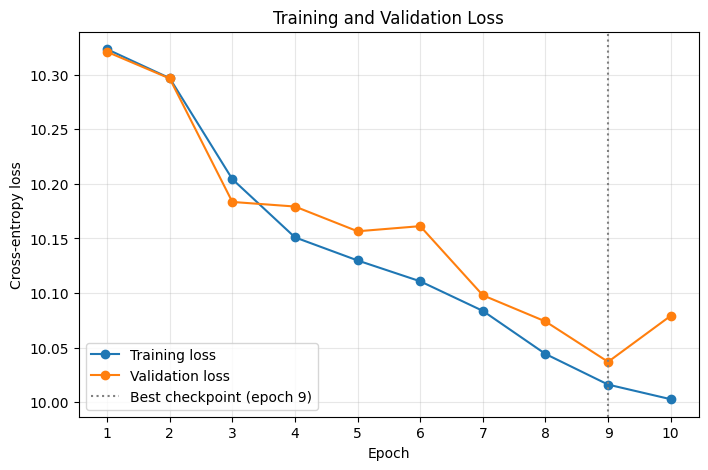

In [19]:
import matplotlib.pyplot as plt


epochs = range(
    1,
    len(train_losses) + 1,
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Training loss",
)

plt.plot(
    epochs,
    validation_losses,
    marker="o",
    label="Validation loss",
)

if best_epoch is not None:
    plt.axvline(
        best_epoch,
        color="grey",
        linestyle=":",
        label=f"Best checkpoint (epoch {best_epoch})",
    )

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training and Validation Loss")
plt.xticks(list(epochs))
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Now let's calculate Hit@10 for the best checkpoint saved during training.

Remember that this uses the validation data, not the test data. We can use the result to compare different model configurations before choosing our final model.


In [20]:
def evaluate_hit_at_k(
    model: nn.Module,
    dataloader: DataLoader,
    device: torch.device,
    k: int,
) -> float:
    model.eval()

    total_hits = 0
    total_targets = 0

    with torch.no_grad():
        for batch in tqdm(
            dataloader,
            desc=f"Calculating Hit@{k}",
        ):
            batch = {
                name: tensor.to(device)
                for name, tensor in batch.items()
            }

            logits = model(
                batch["input_item_classes"],
                batch["input_watch_features"],
                batch["input_action_states"],
                batch["input_timestamps"],
                batch["history_mask"],
            )

            valid_mask = (
                batch["target_item_classes"]
                != PADDING_LABEL
            )

            valid_logits = logits[valid_mask]

            valid_targets = (
                batch["target_item_classes"][valid_mask]
            )

            if valid_targets.numel() == 0:
                continue

            top_k_items = valid_logits.topk(
                k=k,
                dim=-1,
            ).indices

            hits = (
                top_k_items
                == valid_targets.unsqueeze(-1)
            ).any(dim=-1)

            total_hits += hits.sum().item()
            total_targets += hits.numel()

    if total_targets == 0:
        raise ValueError(
            "The validation data contained no valid targets."
        )

    return total_hits / total_targets


In [21]:
validation_hit_at_10 = evaluate_hit_at_k(
    model=model,
    dataloader=validation_dataloader,
    device=device,
    k=10,
)

print(
    "Best validation loss:",
    f"{best_validation_loss:.4f}",
)

print(
    "Validation Hit@10:",
    f"{validation_hit_at_10:.4f}",
)


Calculating Hit@10:   0%|          | 0/51 [00:00<?, ?it/s]

Best validation loss: 10.0370
Validation Hit@10: 0.0062


## Task 3.9: Benchmarking our final HSTU model and freezing its state

Once you're happy with your config based on the validation results from Task 3.8, it's time to check performance on the test set. This is the one and only time we touch it, since it's meant to represent genuinely unseen future data, and repeatedly peeking at it while tuning would quietly turn it into a second validation set.

**Why not just use accuracy or F1?**

It's tempting to reach for familiar classification metrics here, like accuracy or F1 score, since we've been describing next item prediction as a classification problem all along. But those metrics don't translate cleanly to a catalogue of over 31,000 items.

A standard F1 score needs a single yes or no prediction per class, then compares that against the ground truth using true positives, false positives, and false negatives. If we tried to compute it directly here, almost every one of our 31,000 item classes would trivially count as a true negative on almost every single prediction, since the model correctly says "no" to nearly the entire catalogue every time. That would flood the score with near perfect results from items that were barely ever relevant, drowning out any real signal about whether the model is actually any good.

What we actually care about is a ranking question, not a strict classification one: "out of the videos the model was most confident about, how many of them turned out to be right?" That's a much better match for how a real recommender is used. Nobody scrolls through the full ranked list of 31,000 videos, they see a short list, so what matters is whether the right video made it into that short list at all.

This is why recommendation systems generally use versions of these metrics adapted to the top K predictions instead of the full catalogue:

- **Hit@K**: did the true next item show up anywhere in the model's top K guesses? Simple yes or no, averaged across all predictions.
- **Precision@K**: of the K items the model put forward, what fraction were actually relevant? Since we only have one true next item per position, this ends up being 1/K on a hit and 0 otherwise.
- **Recall@K**: of all the relevant items out there, what fraction did the top K capture? With exactly one relevant item per position, this collapses to the same value as Hit@K here.
- **F1@K**: the harmonic mean of Precision@K and Recall@K, giving a single balanced number that reflects both at once.

We'll compute all four so you can see how they relate to each other, even though with a single ground truth item per position, Recall@K and Hit@K will always come out identical, and F1@K will follow directly from Precision@K and Recall@K.

**Your Job**

Run your final, tuned model over the test set and compute Hit@10, Precision@10, Recall@10, and F1@10.


In [22]:
def compute_metrics_at_k(
    logits: torch.Tensor,
    target_item_classes: torch.Tensor,
    k: int = 10,
) -> tuple[int, int]:
    valid_mask = target_item_classes != PADDING_LABEL

    valid_logits = logits[valid_mask]
    valid_targets = target_item_classes[valid_mask]

    top_k_items = valid_logits.topk(k, dim=-1).indices
    hits = (top_k_items == valid_targets.unsqueeze(-1)).any(dim=-1)

    return hits.sum().item(), hits.numel()


K: int = 10

model.eval()
total_hits = 0
total_predictions = 0

with torch.no_grad():
    for batch in tqdm(test_dataloader, desc="Testing"):
        batch = {name: tensor.to(device) for name, tensor in batch.items()}

        logits = model(
            batch["input_item_classes"],
            batch["input_watch_features"],
            batch["input_action_states"],
            batch["input_timestamps"],
            batch["history_mask"],
        )

        hits, predictions = compute_metrics_at_k(logits, batch["target_item_classes"], k=K)
        total_hits += hits
        total_predictions += predictions

# with exactly one relevant item per position, hit rate, precision@k,
# and recall@k all reduce to variations on the same underlying number
hit_at_k = total_hits / total_predictions
precision_at_k = hit_at_k / K
recall_at_k = hit_at_k
f1_at_k = (
    2 * (precision_at_k * recall_at_k) / (precision_at_k + recall_at_k)
    if (precision_at_k + recall_at_k) > 0
    else 0.0
)

print(f"Hit@{K}: {hit_at_k:.4f}")
print(f"Precision@{K}: {precision_at_k:.4f}")
print(f"Recall@{K}: {recall_at_k:.4f}")
print(f"F1@{K}: {f1_at_k:.4f}")

# freeze the model's weights so nothing here can accidentally change again
for parameter in model.parameters():
    parameter.requires_grad = False


Testing:   0%|          | 0/51 [00:00<?, ?it/s]

Hit@10: 0.0034
Precision@10: 0.0003
Recall@10: 0.0034
F1@10: 0.0006


Our final model achieved a Hit@10 of 0.0034 on the test data. This means the true next item appeared in the model's 10 highest-scoring predictions approximately 0.34% of the time.

Although this value may appear low, the model was choosing from 31,496 possible items. A random recommender would achieve an expected Hit@10 of approximately 0.00032, or 0.032%.

Our model therefore performed around 10.7 times better than random guessing, suggesting that it learned useful patterns from the interaction sequences.

Precision@10, Recall@10, and F1@10 provide limited additional information in this particular task because each sequence position has exactly one relevant next item. Recall@10 is therefore identical to Hit@10, while Precision@10 and F1@10 follow directly from it.


<br>

**How do we improve this?**

There are several things we could try to improve the model:

- **Train on more interactions.** Sequential recommenders benefit from seeing lots of examples of how user interests develop. A larger dataset would give the model more opportunities to learn useful patterns.
- **Use longer histories.** We limited each input sequence to 50 interactions to keep training manageable. Increasing `MAX_SEQUENCE_LENGTH` could give the model more context about each user's interests, although it would also increase memory use and training time.
- **Tune the hyperparameters.** We could experiment with values such as `MODEL_DIM`, `NUMBER_OF_HSTU_LAYERS`, `LEARNING_RATE`, and `NUMBER_OF_EPOCHS`, using validation loss and validation Hit@10 to compare the results.
- **Add dropout or weight decay.** These regularisation techniques may help if the loss graph suggests the model is overfitting.
- **Use more informative features.** Creator information, session context, video duration, and additional timing features could all provide useful signals that aren't currently represented by the model.
- **Use overlapping sequence windows.** Our current sequence construction divides long histories into separate non-overlapping windows. Overlapping windows would create more training examples and preserve more transitions between nearby interactions.
- **Improve the training objective.** We currently ask the model to predict one exact next item from the complete catalogue. Alternatives such as sampled negatives, in-batch negatives, or a combination of next-item and action prediction could give the model a stronger learning signal.
- **Use a two-stage recommendation system.** A production system would rarely rank every item in its full catalogue at once. It would normally retrieve a smaller set of plausible candidates first, then use a model like our HSTU to rank them. Predicting from a pool of a few hundred relevant candidates would be much easier than choosing directly from all 31,496 items.
- **Compare against stronger baselines.** Beating random guessing is encouraging, but the next useful comparison would be a popularity baseline that always recommends the most common training items. This would tell us whether the HSTU has learned more than which videos are generally popular.

It is also worth remembering that predicting the exact next video is an extremely difficult task. A user may enjoy thousands of possible videos, but our test data records only the one they happened to watch next. The model can therefore produce a sensible recommendation and still be marked wrong because it didn't reproduce that exact historical outcome.

One important rule still applies: we shouldn't now change the model based on its test results and then evaluate it on the same test data again. Doing that would turn our test set into another validation set. If we wanted to continue improving the model properly, we would use the validation data for those decisions and reserve a new unseen test set for the final comparison.


## Task 3.10: Exporting the Final Model 📦

Our HSTU has now been trained and evaluated using the ShortVideo catalogue. However, the reels we'll recommend in Section 4 come from a separate workshop catalogue containing around 300 Instagram reels.

The two catalogues use different item IDs and embedding rows. For example, ShortVideo embedding row 0 and workshop embedding row 0 represent completely different videos. This means we cannot pass workshop row numbers into the model while it still contains the ShortVideo embedding lookup.

Instead, we'll save the parts of the model that were learned during training:

- the projection that maps 768-dimensional content embeddings into the model's working space
- the watch and action feature encoders
- the HSTU blocks
- the relative position and time biases

We won't transfer the frozen ShortVideo content embedding lookup, since that belongs specifically to the ShortVideo catalogue.

We'll also define a ReelsClassifier class. This class will provide a simpler interface for inference by handling the conversion from workshop item IDs to embedding rows, running the model, removing reels that have already been viewed, and returning readable reel metadata.

We can define the class now, but we won't create the actual reels_classifier object until Section 4. We first need to load the workshop catalogue and create a workshop-specific ReelsRecommender.


In [23]:
MODEL_CONFIG = {
    "model_dim": MODEL_DIM,
    "number_of_watch_features": len(
        WATCH_FEATURE_COLUMNS
    ),
    "number_of_action_columns": len(
        ACTION_COLUMNS
    ),
    "action_embedding_dim": ACTION_EMBEDDING_DIM,
    "number_of_layers": NUMBER_OF_HSTU_LAYERS,
    "max_relative_position": MAX_RELATIVE_POSITION,
    "number_of_time_buckets": NUMBER_OF_TIME_BUCKETS,
}

# Save every trained parameter except the frozen
# ShortVideo content embedding lookup.
TRANSFERABLE_MODEL_STATE = {
    name: tensor.detach().cpu().clone()
    for name, tensor in model.state_dict().items()
    if name
    != (
        "event_encoder.item_encoder."
        "content_embeddings.weight"
    )
}

MODEL_CHECKPOINT_PATH = Path(
    "reels_recommender_transferable_state.pt"
)

torch.save(
    {
        "model_config": MODEL_CONFIG,
        "model_state": TRANSFERABLE_MODEL_STATE,
        "watch_feature_columns": WATCH_FEATURE_COLUMNS,
        "action_columns": ACTION_COLUMNS,
    },
    MODEL_CHECKPOINT_PATH,
)

print(
    "Saved the trained parameters needed "
    "for the workshop catalogue."
)


Saved the trained parameters needed for the workshop catalogue.


In [24]:
class ReelsClassifier:
    """
    Provides a simple inference interface around a
    catalogue-specific ReelsRecommender.

    The class is defined in Section 3, but an instance will
    only be created in Section 4 after the workshop catalogue
    and its content embeddings have been loaded.
    """

    def __init__(
        self,
        model: ReelsRecommender,
        reels_df: pd.DataFrame,
        reel_embedding_index_df: pd.DataFrame,
        watch_feature_columns: list[str],
        action_columns: list[str],
        device: torch.device,
        max_sequence_length: int,
    ):
        self.model = model
        self.reels_df = reels_df.copy()
        self.reel_embedding_index_df = (
            reel_embedding_index_df.copy()
        )
        self.watch_feature_columns = (
            watch_feature_columns
        )
        self.action_columns = action_columns
        self.device = device
        self.max_sequence_length = max_sequence_length

        self.item_id_to_embedding_row = dict(
            zip(
                self.reel_embedding_index_df["item_id"],
                self.reel_embedding_index_df[
                    "embedding_row"
                ],
            )
        )

    def _encode_sequence(
        self,
        interaction_sequence: pd.DataFrame,
    ) -> dict:
        if interaction_sequence.empty:
            raise ValueError(
                "The interaction sequence is empty."
            )

        sequence_df = (
            interaction_sequence
            .sort_values("timestamp")
            .tail(self.max_sequence_length)
            .reset_index(drop=True)
            .copy()
        )

        required_columns = (
            ["item_id", "timestamp"]
            + self.watch_feature_columns
            + self.action_columns
        )

        missing_columns = [
            column
            for column in required_columns
            if column not in sequence_df.columns
        ]

        if missing_columns:
            raise ValueError(
                "The interaction sequence is missing "
                f"these columns: {missing_columns}"
            )

        unknown_item_ids = sorted({
            item_id
            for item_id in sequence_df["item_id"]
            if item_id
            not in self.item_id_to_embedding_row
        })

        if unknown_item_ids:
            raise ValueError(
                "No workshop embedding was found for: "
                f"{unknown_item_ids}"
            )

        item_classes = (
            sequence_df["item_id"]
            .map(self.item_id_to_embedding_row)
            .to_numpy(dtype=np.int64)
        )

        watch_features = (
            sequence_df[self.watch_feature_columns]
            .fillna(0.0)
            .to_numpy(dtype=np.float32)
        )

        # Convert action values into the three states
        # used during training:
        # 0 = false, 1 = true, 2 = unavailable.
        action_states = (
            sequence_df[self.action_columns]
            .astype("Int8")
            .fillna(2)
            .to_numpy(dtype=np.int64)
        )

        timestamps = (
            sequence_df["timestamp"]
            .to_numpy(dtype=np.int64)
        )

        input_item_classes = torch.tensor(
            item_classes,
            dtype=torch.long,
            device=self.device,
        ).unsqueeze(0)

        input_watch_features = torch.tensor(
            watch_features,
            dtype=torch.float32,
            device=self.device,
        ).unsqueeze(0)

        input_action_states = torch.tensor(
            action_states,
            dtype=torch.long,
            device=self.device,
        ).unsqueeze(0)

        input_timestamps = torch.tensor(
            timestamps,
            dtype=torch.long,
            device=self.device,
        ).unsqueeze(0)

        history_mask = torch.ones_like(
            input_item_classes,
            dtype=torch.bool,
            device=self.device,
        )

        return {
            "input_item_classes": input_item_classes,
            "input_watch_features": input_watch_features,
            "input_action_states": input_action_states,
            "input_timestamps": input_timestamps,
            "history_mask": history_mask,
            "seen_item_ids": set(
                sequence_df["item_id"]
            ),
        }

    def predict_next_n_reels(
        self,
        interaction_sequence: pd.DataFrame,
        n: int,
    ) -> pd.DataFrame:
        if n <= 0:
            raise ValueError(
                "n must be greater than zero."
            )

        encoded_sequence = self._encode_sequence(
            interaction_sequence
        )

        self.model.eval()

        with torch.no_grad():
            logits = self.model(
                encoded_sequence[
                    "input_item_classes"
                ],
                encoded_sequence[
                    "input_watch_features"
                ],
                encoded_sequence[
                    "input_action_states"
                ],
                encoded_sequence[
                    "input_timestamps"
                ],
                encoded_sequence["history_mask"],
            )

        # The final valid sequence position represents
        # the model's prediction of what should come next.
        next_item_scores = logits[0, -1]

        eligible_reels_df = self.reels_df[
            self.reels_df[
                "approved_for_workshop"
            ].fillna(False)
        ].copy()

        # Remove reels already present in the history.
        eligible_reels_df = eligible_reels_df[
            ~eligible_reels_df["item_id"].isin(
                encoded_sequence["seen_item_ids"]
            )
        ].copy()

        if eligible_reels_df.empty:
            raise ValueError(
                "There are no eligible unseen reels "
                "left to recommend."
            )

        eligible_embedding_rows = torch.tensor(
            eligible_reels_df[
                "embedding_row"
            ].to_numpy(dtype=np.int64),
            dtype=torch.long,
            device=self.device,
        )

        eligible_scores = next_item_scores[
            eligible_embedding_rows
        ]

        number_to_return = min(
            n,
            len(eligible_reels_df),
        )

        top_positions = torch.topk(
            eligible_scores,
            k=number_to_return,
        ).indices

        top_positions_numpy = (
            top_positions.cpu().numpy()
        )

        recommendations_df = (
            eligible_reels_df
            .iloc[top_positions_numpy]
            .copy()
            .reset_index(drop=True)
        )

        recommendations_df["score"] = (
            eligible_scores[top_positions]
            .detach()
            .cpu()
            .numpy()
        )

        recommendations_df.insert(
            0,
            "rank",
            range(
                1,
                len(recommendations_df) + 1,
            ),
        )

        return recommendations_df[
            [
                "rank",
                "item_id",
                "reel_id",
                "title",
                "category",
                "content_format",
                "tags",
                "primary_creator",
                "audio_type",
                "language",
                "duration_sec",
                "instagram_url",
                "score",
            ]
        ]


print(
    "ReelsClassifier has been defined. "
    "We'll instantiate it after loading the "
    "workshop catalogue in Section 4."
)


ReelsClassifier has been defined. We'll instantiate it after loading the workshop catalogue in Section 4.


<hr>

# Section 4: Using Your Recommender

We've provided a UI that will show you reels from a pool of around 300 workshop-approved Instagram reels and record how you interact with them.

These reels are separate from the ShortVideo catalogue used to train our model. The model hasn't seen these exact reels during training, but their content embeddings were generated using the same encoder and processing steps as the ShortVideo embeddings.

In this section, we'll:

1. Create our own short scrolling sequence using the workshop app.
2. Load the workshop reel catalogue and its content embeddings.
3. Transfer the parameters learned in Section 3 into a workshop-specific recommender.
4. Paste in our scrolling history.
5. Ask the model to recommend the next 10 reels.


## Task 4.0: Doomscroll 😵‍💫

Before your model can make personalised recommendations, it needs some interactions to learn from.

Open the workshop doomscrolling app using the link below:

[Open the workshop app](https://edi-ai-app-reels-app-g9hix2dhtyjvntnkkvnzcd.streamlit.app/)

Scroll through the reels and interact with them naturally. The app will record information such as:

- which reels you viewed
- how long you watched each reel
- whether you liked a reel
- whether you gave it negative feedback
- any other actions available in the app

Try to scroll through at least 20 reels so the model has enough information to begin picking up on your interests.

Once you're finished, use the app's copy button to copy your scrolling data. Keep it somewhere safe for now, as you'll paste it into the notebook in Task 4.3.


## Task 4.1: Load the Workshop Reel Catalogue 📂

The model was trained using the ShortVideo catalogue, but we now want it to recommend from a separate catalogue of 298 workshop reels.

The workshop dataset contains:

- `reels.parquet`, containing metadata about each workshop reel
- `reel_content_embeddings.npy`, containing one 768-dimensional content embedding for each reel
- `reel_embedding_index.csv`, mapping each workshop `item_id` to its embedding row

The ShortVideo and workshop catalogues each have their own embedding rows. For example, ShortVideo embedding row 0 and workshop embedding row 0 represent completely different videos.

This is not a problem as long as each row number is only used with the embedding array it belongs to. We'll create a new instance of `ReelsRecommender` containing the workshop embeddings rather than passing workshop row numbers into the original ShortVideo model.

We'll load the main catalogue from its Parquet file rather than its CSV file. Parquet preserves values such as tag lists and booleans without converting them into strings.

**Your Job**

1. Add the workshop dataset to your notebook using the **Add Input** option in the right sidebar.
2. Load the workshop catalogue into a Pandas dataframe.
3. Load the workshop content embeddings into a NumPy array.
4. Load the embedding index into another Pandas dataframe.
5. Run the provided checks to make sure the three files agree with each other.

The dataset can be found here:

https://www.kaggle.com/datasets/conoroshea46/ediai-workshop-reels-2026


In [25]:
from pathlib import Path
import pandas as pd
import numpy as np

WORKSHOP_DATASET_DIR_PATH = Path(
    "/kaggle/input/datasets/"
    "conoroshea46/"
    "ediai-workshop-reels-2026"
)

reels_df: pd.DataFrame = pd.read_parquet(
    WORKSHOP_DATASET_DIR_PATH / "reels.parquet"
)

reel_content_embeddings: np.ndarray = np.load(
    WORKSHOP_DATASET_DIR_PATH
    / "reel_content_embeddings.npy"
)

reel_embedding_index_df: pd.DataFrame = pd.read_csv(
    WORKSHOP_DATASET_DIR_PATH
    / "reel_embedding_index.csv"
)


In [26]:
required_reel_columns = [
    "reel_id",
    "item_id",
    "category",
    "content_format",
    "title",
    "tags",
    "primary_creator",
    "audio_type",
    "language",
    "instagram_url",
    "labelled_by",
    "labelled_at",
    "approved_for_workshop",
    "content_text",
    "embedding_row",
    "source",
    "duration_sec",
    "s3_bucket",
    "s3_key",
    "s3_uri",
]

missing_reel_columns = [
    column
    for column in required_reel_columns
    if column not in reels_df.columns
]

if missing_reel_columns:
    raise ValueError(
        "The workshop reel catalogue is missing columns: "
        f"{missing_reel_columns}"
    )

if reels_df["reel_id"].duplicated().any():
    raise ValueError(
        "The workshop catalogue contains duplicate reel IDs."
    )

if reels_df["item_id"].duplicated().any():
    raise ValueError(
        "The workshop catalogue contains duplicate item IDs."
    )

if reel_embedding_index_df["item_id"].duplicated().any():
    raise ValueError(
        "The workshop embedding index contains "
        "duplicate item IDs."
    )

if len(reels_df) != len(reel_content_embeddings):
    raise ValueError(
        "The number of workshop reels does not match "
        "the number of content embeddings."
    )

if len(reels_df) != len(reel_embedding_index_df):
    raise ValueError(
        "The number of workshop reels does not match "
        "the number of embedding index rows."
    )

if reel_content_embeddings.ndim != 2:
    raise ValueError(
        "The workshop content embeddings must be stored "
        "in a two-dimensional array."
    )

if reel_content_embeddings.shape[1] != CONTENT_EMBEDDING_DIM:
    raise ValueError(
        "The workshop and ShortVideo content embeddings "
        "have different dimensions. "
        f"Expected {CONTENT_EMBEDDING_DIM}, but found "
        f"{reel_content_embeddings.shape[1]}."
    )

if not np.isfinite(reel_content_embeddings).all():
    raise ValueError(
        "The workshop content embeddings contain "
        "NaN or infinite values."
    )

embedding_norms = np.linalg.norm(
    reel_content_embeddings,
    axis=1,
)

if not np.allclose(
    embedding_norms,
    1.0,
    atol=1e-4,
):
    raise ValueError(
        "The workshop content embeddings are not "
        "L2-normalised."
    )

valid_embedding_rows = reels_df["embedding_row"].between(
    0,
    len(reel_content_embeddings) - 1,
)

if not valid_embedding_rows.all():
    raise ValueError(
        "At least one embedding_row falls outside "
        "reel_content_embeddings."
    )

index_check_df = reels_df[
    ["item_id", "reel_id", "embedding_row"]
].merge(
    reel_embedding_index_df[
        ["item_id", "reel_id", "embedding_row"]
    ],
    on="item_id",
    how="outer",
    suffixes=("_reels", "_index"),
    indicator=True,
)

invalid_index_rows = index_check_df[
    (index_check_df["_merge"] != "both")
    | (
        index_check_df["reel_id_reels"]
        != index_check_df["reel_id_index"]
    )
    | (
        index_check_df["embedding_row_reels"]
        != index_check_df["embedding_row_index"]
    )
]

if not invalid_index_rows.empty:
    raise ValueError(
        "reels_df and reel_embedding_index_df "
        "contain different item embedding mappings."
    )

if not reels_df["s3_bucket"].eq(
    "edinburghai-reels-workshop-2026"
).all():
    raise ValueError(
        "At least one reel points to an unexpected S3 bucket."
    )

if not reels_df["s3_key"].str.startswith(
    "videos/videos/"
).all():
    raise ValueError(
        "At least one reel has an unexpected S3 key."
    )

print(f"Loaded {len(reels_df):,} workshop reels")

print(
    "Approved workshop reels:",
    f"{reels_df['approved_for_workshop'].fillna(False).sum():,}",
)

print(
    "Reel content embeddings shape:",
    reel_content_embeddings.shape,
)

print(
    "Embedding index rows:",
    f"{len(reel_embedding_index_df):,}",
)

print(
    "Embedding norm range:",
    f"{embedding_norms.min():.6f} to "
    f"{embedding_norms.max():.6f}",
)

display(reels_df.head())


Loaded 298 workshop reels
Approved workshop reels: 298
Reel content embeddings shape: (298, 768)
Embedding index rows: 298
Embedding norm range: 1.000000 to 1.000000


,reel_id,item_id,category,content_format,title,tags,primary_creator,audio_type,language,instagram_url,...,s3_bucket,s3_key,s3_uri,labelled_by,labelled_at,approved_for_workshop,content_text,embedding_row,source,duration_sec
0,C0uLmD9PRCE,workshop:C0uLmD9PRCE,finance_money_meme,meme,joking about getting the ick from a girl becau...,"[humor, satire, finance, taxevasion]",@youraveragefinancebro,trending_audio,en,https://www.instagram.com/p/C0uLmD9PRCE/,...,edinburghai-reels-workshop-2026,videos/videos/C0uLmD9PRCE.mp4,s3://edinburghai-reels-workshop-2026/videos/vi...,unknown,2026-09-11,True,Title: joking about getting the ick from a gir...,0,workshop_instagram_reels,8.548
1,C2P0yXdugGf,workshop:C2P0yXdugGf,work_relatable_brainrot,meme,joking that you only work hard so you can plea...,"[humor, corporate, larp, shareholdervalue]",@corporateweapon,trending_audio,en,https://www.instagram.com/p/C2P0yXdugGf/,...,edinburghai-reels-workshop-2026,videos/videos/C2P0yXdugGf.mp4,s3://edinburghai-reels-workshop-2026/videos/vi...,unknown,2026-09-11,True,Title: joking that you only work hard so you c...,1,workshop_instagram_reels,11.367
2,C2gRdz5LI25,workshop:C2gRdz5LI25,internship_meme,meme,joking that your internship managers will thin...,"[internship, humor, relatable, satire]",@afinancebro,trending_audio,en,https://www.instagram.com/p/C2gRdz5LI25/,...,edinburghai-reels-workshop-2026,videos/videos/C2gRdz5LI25.mp4,s3://edinburghai-reels-workshop-2026/videos/vi...,unknown,2026-09-11,True,Title: joking that your internship managers wi...,2,workshop_instagram_reels,12.200
3,C5rNmy6uSaQ,workshop:C5rNmy6uSaQ,student_relatable_meme,meme,watching marketing/management students not kno...,"[finance, university, humor]",@fitfinancebro,original_audio,en,https://www.instagram.com/p/C5rNmy6uSaQ/,...,edinburghai-reels-workshop-2026,videos/videos/C5rNmy6uSaQ.mp4,s3://edinburghai-reels-workshop-2026/videos/vi...,unknown,2026-09-11,True,Title: watching marketing/management students ...,3,workshop_instagram_reels,11.467
4,C6T54MMOrAT,workshop:C6T54MMOrAT,pop_culture_brainrot,meme,baby gronk talks about hugging livvy dunne,"[babygronk, livvydunne, brainrot]",@maddensanmiguel,original_audio,en,https://www.instagram.com/p/C6T54MMOrAT/,...,edinburghai-reels-workshop-2026,videos/videos/C6T54MMOrAT.mp4,s3://edinburghai-reels-workshop-2026/videos/vi...,unknown,2026-09-11,True,Title: baby gronk talks about hugging livvy du...,4,workshop_instagram_reels,10.567


## Task 4.2: Create the Workshop Recommender 🔁

We can now create the version of our recommender that will work with the workshop catalogue.

We'll create a new `ReelsRecommender` whose internal content embedding lookup contains the workshop reels rather than the ShortVideo items.

A newly created model normally begins with random parameters. However, we don't want to train another model from scratch. Instead, we'll load the parameters learned during Section 3 into the new model.

We'll transfer:

- the trained item projection
- the watch and action encoders
- the HSTU blocks
- the relative position and time biases

We won't transfer the frozen ShortVideo content embedding lookup. The new model will use the workshop content embeddings in its place.

Once the workshop-specific recommender is ready, we'll use it to instantiate the `ReelsClassifier` class we defined in Section 3.


In [27]:
workshop_recommender = ReelsRecommender(
    content_embeddings=reel_content_embeddings,
    model_dim=MODEL_CONFIG["model_dim"],
    number_of_watch_features=(
        MODEL_CONFIG["number_of_watch_features"]
    ),
    number_of_action_columns=(
        MODEL_CONFIG["number_of_action_columns"]
    ),
    action_embedding_dim=(
        MODEL_CONFIG["action_embedding_dim"]
    ),
    number_of_layers=(
        MODEL_CONFIG["number_of_layers"]
    ),
    max_relative_position=(
        MODEL_CONFIG["max_relative_position"]
    ),
    number_of_time_buckets=(
        MODEL_CONFIG["number_of_time_buckets"]
    ),
)

load_result = workshop_recommender.load_state_dict(
    TRANSFERABLE_MODEL_STATE,
    strict=False,
)

expected_missing_keys = {
    (
        "event_encoder.item_encoder."
        "content_embeddings.weight"
    )
}

if set(load_result.missing_keys) != expected_missing_keys:
    raise ValueError(
        "Unexpected parameters were missing while "
        "creating the workshop recommender: "
        f"{load_result.missing_keys}"
    )

if load_result.unexpected_keys:
    raise ValueError(
        "Unexpected parameters were found while "
        "creating the workshop recommender: "
        f"{load_result.unexpected_keys}"
    )

workshop_recommender = workshop_recommender.to(device)
workshop_recommender.eval()

for parameter in workshop_recommender.parameters():
    parameter.requires_grad = False

reels_classifier = ReelsClassifier(
    model=workshop_recommender,
    reels_df=reels_df,
    reel_embedding_index_df=(
        reel_embedding_index_df
    ),
    watch_feature_columns=WATCH_FEATURE_COLUMNS,
    action_columns=ACTION_COLUMNS,
    device=device,
    max_sequence_length=MAX_SEQUENCE_LENGTH,
)

print(
    "reels_classifier is ready to recommend "
    "from the workshop catalogue."
)


reels_classifier is ready to recommend from the workshop catalogue.


## Task 4.3: Load Your Scrolling Sequence 📋

Rather than exporting a file and uploading it, the doomscrolling app gives you a block of JSON text to copy. All you need to do is paste it into a Python variable as a string literal.

**What does the JSON look like?**

The app's export is a JSON object containing some session-level information, such as `session_id` and `started_at`, alongside the part we actually care about: a list of individual events under the `"interactions"` key.

This is called nested JSON, which just means that some data is stored inside another piece of data. Before we can turn the interactions into a dataframe, we need to reach inside the outer object and pull out that list.

It's worth noting that what you're pasting here is only today's workshop session, not your full scrolling history. A large platform would usually already have a much longer history stored for each user, potentially covering months or years of interactions. It could retrieve that history and append the user's latest session before making a recommendation.

We've scaled that down for simplicity. The workshop JSON gives us a small, self-contained example of the much larger sequence that a production recommender would normally process.

**Turning the pasted string into something useful**

`json.loads()` parses the pasted JSON string and turns it into a Python dictionary. From there, `parsed_scroll_log["interactions"]` gives us the list of individual events, which `pd.DataFrame()` can turn into a table.

The app does not directly record every feature used during training, so we'll also derive:

- `watch_ratio_raw`, calculated as watch time divided by reel duration
- `watch_ratio`, clipped to be between 0 and 1
- `watched_over_duration`, showing whether watch time exceeded the reel duration
- `long_watch`, showing whether at least 80% of the reel was watched
- `immediate_skip`, showing whether the reel was watched for 3 seconds or less

Actions that weren't available in the app will remain missing rather than being recorded as false. This allows the model to distinguish between:

- 0, meaning false
- 1, meaning true
- 2, meaning unavailable

**Your Job**

Paste your exported scrolling data as a string literal into `my_scroll_log_json`, then run the cell to turn it into a proper interaction sequence.


In [29]:
import json


# TODO: Paste the JSON copied from the app
# between the triple quotes below.
my_scroll_log_json = """
{
  "schema_version": "1.0",
  "source": "workshop_live",
  "session_id": "workshop:session:7fa1cfc7f81c",
  "started_at": 1789734114,
  "interactions": [
    {
      "viewing_id": "workshop:viewing:001",
      "session_id": "workshop:session:7fa1cfc7f81c",
      "sequence_position": 0,
      "item_id": "workshop:DdBeuQKOhcG",
      "reel_id": "DdBeuQKOhcG",
      "timestamp": 1789734114,
      "duration_sec": 12.982,
      "watch_seconds": 10.376,
      "liked": true,
      "negative_feedback": false,
      "clicked": null,
      "commented": null,
      "followed": null,
      "collected": null,
      "forwarded": null
    },
    {
      "viewing_id": "workshop:viewing:002",
      "session_id": "workshop:session:7fa1cfc7f81c",
      "sequence_position": 1,
      "item_id": "workshop:DcxSXlfApLQ",
      "reel_id": "DcxSXlfApLQ",
      "timestamp": 1789734124,
      "duration_sec": 6.759,
      "watch_seconds": 9.75,
      "liked": false,
      "negative_feedback": true,
      "clicked": null,
      "commented": null,
      "followed": null,
      "collected": null,
      "forwarded": null
    },
    {
      "viewing_id": "workshop:viewing:003",
      "session_id": "workshop:session:7fa1cfc7f81c",
      "sequence_position": 2,
      "item_id": "workshop:DdA1ReQTe5Q",
      "reel_id": "DdA1ReQTe5Q",
      "timestamp": 1789734134,
      "duration_sec": 13.333,
      "watch_seconds": 4.34,
      "liked": true,
      "negative_feedback": false,
      "clicked": null,
      "commented": null,
      "followed": null,
      "collected": null,
      "forwarded": null
    },
    {
      "viewing_id": "workshop:viewing:004",
      "session_id": "workshop:session:7fa1cfc7f81c",
      "sequence_position": 3,
      "item_id": "workshop:DaQvrUlBLjO",
      "reel_id": "DaQvrUlBLjO",
      "timestamp": 1789734138,
      "duration_sec": 13.585,
      "watch_seconds": 3.789,
      "liked": true,
      "negative_feedback": false,
      "clicked": null,
      "commented": null,
      "followed": null,
      "collected": null,
      "forwarded": null
    },
    {
      "viewing_id": "workshop:viewing:005",
      "session_id": "workshop:session:7fa1cfc7f81c",
      "sequence_position": 4,
      "item_id": "workshop:DWt3H5ACp1J",
      "reel_id": "DWt3H5ACp1J",
      "timestamp": 1789734142,
      "duration_sec": 12.312,
      "watch_seconds": 1.872,
      "liked": true,
      "negative_feedback": false,
      "clicked": null,
      "commented": null,
      "followed": null,
      "collected": null,
      "forwarded": null
    },
    {
      "viewing_id": "workshop:viewing:006",
      "session_id": "workshop:session:7fa1cfc7f81c",
      "sequence_position": 5,
      "item_id": "workshop:DXsSSVggVjW",
      "reel_id": "DXsSSVggVjW",
      "timestamp": 1789734144,
      "duration_sec": 12.7,
      "watch_seconds": 0.741,
      "liked": false,
      "negative_feedback": false,
      "clicked": null,
      "commented": null,
      "followed": null,
      "collected": null,
      "forwarded": null
    },
    {
      "viewing_id": "workshop:viewing:007",
      "session_id": "workshop:session:7fa1cfc7f81c",
      "sequence_position": 6,
      "item_id": "workshop:DcOGKYUq6ir",
      "reel_id": "DcOGKYUq6ir",
      "timestamp": 1789734145,
      "duration_sec": 13.028,
      "watch_seconds": 1.378,
      "liked": false,
      "negative_feedback": false,
      "clicked": null,
      "commented": null,
      "followed": null,
      "collected": null,
      "forwarded": null
    },
    {
      "viewing_id": "workshop:viewing:008",
      "session_id": "workshop:session:7fa1cfc7f81c",
      "sequence_position": 7,
      "item_id": "workshop:DdBjLWSg-m8",
      "reel_id": "DdBjLWSg-m8",
      "timestamp": 1789734146,
      "duration_sec": 18.7,
      "watch_seconds": 1.237,
      "liked": false,
      "negative_feedback": true,
      "clicked": null,
      "commented": null,
      "followed": null,
      "collected": null,
      "forwarded": null
    },
    {
      "viewing_id": "workshop:viewing:009",
      "session_id": "workshop:session:7fa1cfc7f81c",
      "sequence_position": 8,
      "item_id": "workshop:DcbM2lQNb7d",
      "reel_id": "DcbM2lQNb7d",
      "timestamp": 1789734148,
      "duration_sec": 13.91,
      "watch_seconds": 2.119,
      "liked": true,
      "negative_feedback": false,
      "clicked": null,
      "commented": null,
      "followed": null,
      "collected": null,
      "forwarded": null
    },
    {
      "viewing_id": "workshop:viewing:010",
      "session_id": "workshop:session:7fa1cfc7f81c",
      "sequence_position": 9,
      "item_id": "workshop:DEibBnMIpRC",
      "reel_id": "DEibBnMIpRC",
      "timestamp": 1789734150,
      "duration_sec": 12.749,
      "watch_seconds": 3.306,
      "liked": true,
      "negative_feedback": false,
      "clicked": null,
      "commented": null,
      "followed": null,
      "collected": null,
      "forwarded": null
    }
  ]
}
"""

try:
    parsed_scroll_log = json.loads(
        my_scroll_log_json
    )
except json.JSONDecodeError as error:
    raise ValueError(
        "Couldn't parse your scrolling data as JSON. "
        "Check that you copied the complete export, "
        "including its opening and closing brackets."
    ) from error

if "interactions" not in parsed_scroll_log:
    raise ValueError(
        "The pasted JSON does not contain an "
        "'interactions' list."
    )

my_interaction_sequence = pd.DataFrame(
    parsed_scroll_log["interactions"]
)

if my_interaction_sequence.empty:
    raise ValueError(
        "The pasted scrolling session contains "
        "no interactions."
    )

required_recorded_columns = [
    "item_id",
    "timestamp",
    "duration_sec",
    "watch_seconds",
    "liked",
]

missing_recorded_columns = [
    column
    for column in required_recorded_columns
    if column not in my_interaction_sequence.columns
]

if missing_recorded_columns:
    raise ValueError(
        "The scrolling data is missing columns: "
        f"{missing_recorded_columns}"
    )

# The app may use either negative_feedback or
# not_interested for the same action.
if "negative_feedback" not in (
    my_interaction_sequence.columns
):
    if "not_interested" in (
        my_interaction_sequence.columns
    ):
        my_interaction_sequence[
            "negative_feedback"
        ] = my_interaction_sequence[
            "not_interested"
        ]
    else:
        my_interaction_sequence[
            "negative_feedback"
        ] = pd.NA
elif "not_interested" in (
    my_interaction_sequence.columns
):
    my_interaction_sequence[
        "negative_feedback"
    ] = my_interaction_sequence[
        "negative_feedback"
    ].combine_first(
        my_interaction_sequence[
            "not_interested"
        ]
    )

invalid_durations = (
    my_interaction_sequence["duration_sec"].isna()
    | (
        my_interaction_sequence["duration_sec"]
        <= 0
    )
)

if invalid_durations.any():
    raise ValueError(
        "Every interaction needs a positive "
        "duration_sec value."
    )

if my_interaction_sequence[
    "watch_seconds"
].isna().any():
    raise ValueError(
        "Every interaction needs a watch_seconds value."
    )

# Derive the same watch features used during training.
my_interaction_sequence[
    "watch_ratio_raw"
] = (
    my_interaction_sequence["watch_seconds"]
    / my_interaction_sequence["duration_sec"]
)

my_interaction_sequence[
    "watch_ratio"
] = my_interaction_sequence[
    "watch_ratio_raw"
].clip(0, 1)

my_interaction_sequence[
    "watched_over_duration"
] = (
    my_interaction_sequence["watch_ratio_raw"]
    > 1
)

my_interaction_sequence[
    "long_watch"
] = (
    my_interaction_sequence["watch_ratio"]
    >= 0.8
)

my_interaction_sequence[
    "immediate_skip"
] = (
    my_interaction_sequence["watch_seconds"]
    <= 3
)

# Add any actions that weren't available in the app.
# Missing means unavailable, not false.
optional_action_columns = [
    "clicked",
    "commented",
    "followed",
    "collected",
    "forwarded",
]

for column in optional_action_columns:
    if column not in my_interaction_sequence.columns:
        my_interaction_sequence[column] = pd.NA

# These source-specific names must not be passed into
# the model as separate features.
my_interaction_sequence = (
    my_interaction_sequence.drop(
        columns=["hate", "not_interested"],
        errors="ignore",
    )
)

# Preserve false, true, and missing as 0, 1, and NA.
for column in ACTION_COLUMNS:
    if column not in my_interaction_sequence.columns:
        my_interaction_sequence[column] = pd.NA

    my_interaction_sequence[column] = pd.array(
        my_interaction_sequence[column],
        dtype="Int8",
    )

my_interaction_sequence = (
    my_interaction_sequence
    .sort_values("timestamp")
    .reset_index(drop=True)
)

required_model_columns = (
    ["item_id", "timestamp"]
    + WATCH_FEATURE_COLUMNS
    + ACTION_COLUMNS
)

missing_model_columns = [
    column
    for column in required_model_columns
    if column not in my_interaction_sequence.columns
]

if missing_model_columns:
    raise ValueError(
        "The prepared sequence is missing model "
        f"features: {missing_model_columns}"
    )

unknown_item_ids = sorted(
    set(my_interaction_sequence["item_id"])
    - set(reel_embedding_index_df["item_id"])
)

if unknown_item_ids:
    raise ValueError(
        "These viewed reels are not present in the "
        f"workshop catalogue: {unknown_item_ids}"
    )

print(
    f"Loaded {len(my_interaction_sequence)} "
    "interactions from your scrolling session."
)

display(my_interaction_sequence.head())


Loaded 10 interactions from your scrolling session.


,viewing_id,session_id,sequence_position,item_id,reel_id,timestamp,duration_sec,watch_seconds,liked,negative_feedback,clicked,commented,followed,collected,forwarded,watch_ratio_raw,watch_ratio,watched_over_duration,long_watch,immediate_skip
0,workshop:viewing:001,workshop:session:7fa1cfc7f81c,0,workshop:DdBeuQKOhcG,DdBeuQKOhcG,1789734114,12.982,10.376,1,0,<NA>,<NA>,<NA>,<NA>,<NA>,0.799261,0.799261,0,0,0
1,workshop:viewing:002,workshop:session:7fa1cfc7f81c,1,workshop:DcxSXlfApLQ,DcxSXlfApLQ,1789734124,6.759,9.750,0,1,<NA>,<NA>,<NA>,<NA>,<NA>,1.442521,1.000000,1,1,0
2,workshop:viewing:003,workshop:session:7fa1cfc7f81c,2,workshop:DdA1ReQTe5Q,DdA1ReQTe5Q,1789734134,13.333,4.340,1,0,<NA>,<NA>,<NA>,<NA>,<NA>,0.325508,0.325508,0,0,0
3,workshop:viewing:004,workshop:session:7fa1cfc7f81c,3,workshop:DaQvrUlBLjO,DaQvrUlBLjO,1789734138,13.585,3.789,1,0,<NA>,<NA>,<NA>,<NA>,<NA>,0.278911,0.278911,0,0,0
4,workshop:viewing:005,workshop:session:7fa1cfc7f81c,4,workshop:DWt3H5ACp1J,DWt3H5ACp1J,1789734142,12.312,1.872,1,0,<NA>,<NA>,<NA>,<NA>,<NA>,0.152047,0.152047,0,0,1


## Task 4.4: Get Your Next 10 Reels 🔮

Your scrolling sequence is now ready to use.

The `reels_classifier` will:

1. Match each viewed `item_id` to its workshop embedding row.
2. Combine each viewed reel with its watch and action features.
3. Pass the complete sequence through the trained HSTU.
4. Use the final sequence position to predict what should come next.
5. Rank the workshop-approved candidate reels.
6. Remove any reels you've already viewed.
7. Return the 10 highest-scoring recommendations.

**Your Job**

Run the cell below to generate your next 10 reels.


In [30]:
recommended_reels_df = (
    reels_classifier.predict_next_n_reels(
        interaction_sequence=my_interaction_sequence,
        n=10,
    )
)

recommended_reel_ids = (
    recommended_reels_df["reel_id"].tolist()
)

print(recommended_reel_ids)

['Dcql9PbBAiJ', 'DYaHI2TBteT', 'DdBvwgtqEKO', 'Dclmsr2CTiR', 'DcWK2Fyopwt', 'DdC0VnWqdTX', 'DbV6m9EuO-l', 'DZhugVSDiNf', 'DcBBxy-zGdc', 'DcyhPQgzx8q']


## Task 4.5: View your reels in the app

Now you can simply copy across the list of id's output by the cell above into the reels app provided in order to view them and track your behaviour on them too!



<hr>

License

Copyright 2026 [Conor Ryan O'Shea]

Licensed under the Apache License, Version 2.0; you may not use this file except in compliance with the License. You may obtain a copy of the License at: http://www.apache.org/licenses/LICENSE-2.0
